# Compound-Token Transformer (Next Song or SKIP)

- **Input tokens**: song tokens (compound embedding = `song + genre`) and `SKIP` token.
- **Objective**: predict the next event as either `SKIP` or next song token.
- **Model**: causal Transformer with
  - song head: predicts next song token,
  - skip head: predicts whether next token is `SKIP`.

Change: This two-head output keeps your compound-token idea while avoiding the common collapse where one flat softmax predicts `SKIP` for everything.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Avoid torch re-registration crashes in notebooks when autoreload is enabled
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("autoreload", "0")
except Exception:
    pass

import os
import tarfile
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

import matplotlib.pyplot as plt

try:
    import ipywidgets  # noqa: F401
    from tqdm.notebook import tqdm
except Exception:
    # Fallback for environments without Jupyter widgets
    from tqdm import tqdm


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


CONFIG = {
    # Data
    "tar_path_candidates": [
        "./spotify_skip_prediction_mini.tar",
        "../spotify_skip_prediction_mini.tar",
        "/content/drive/MyDrive/spotify_skip_prediction_mini.tar",
        "/content/drive/MyDrive/STAT 4830 Project/spotify_skip_prediction_mini.tar"
    ],
    "extract_dir_candidates": ["./notebooks/extracted_files", "./extracted_files", "..", ".", "/content/drive/MyDrive/notebooks/extracted_files", "/content/drive/MyDrive/"],
    "log_rel_path": "data/training_set/log_mini.csv",
    "track_rel_path": "data/track_features/tf_mini.csv",

    # Columns
    "session_col": "session_id",
    "position_col": "session_position",
    "title_col_candidates": ["title", "track_name", "track_id_clean", "track_id"],
    "genre_col_candidates": ["genre", "genre_name", "track_genre"],
    "skip_col_candidates": ["skip_2", "skipped", "not_skipped"],

    # Auxiliary predictors used when genre is unavailable (and also when available)
    "aux_numeric_cols": [
        "duration", "release_year", "us_popularity_estimate",
        "acousticness", "beat_strength", "bounciness", "danceability", "dyn_range_mean",
        "energy", "flatness", "instrumentalness", "liveness", "loudness", "mechanism",
        "organism", "speechiness", "tempo", "valence",
        "acoustic_vector_0", "acoustic_vector_1", "acoustic_vector_2", "acoustic_vector_3",
        "acoustic_vector_4", "acoustic_vector_5", "acoustic_vector_6", "acoustic_vector_7",
        "session_length", "hour_of_day", "hist_user_behavior_n_seekfwd", "hist_user_behavior_n_seekback",
    ],
    "aux_categorical_cols": [
        "mode", "key", "time_signature", "context_type",
        "hist_user_behavior_reason_start", "hist_user_behavior_reason_end",
        "premium", "hist_user_behavior_is_shuffle", "context_switch",
        "no_pause_before_play", "short_pause_before_play", "long_pause_before_play",
    ],

    # Split + vocab
    "test_size": 0.20,
    "val_size_within_train": 0.125,  # 12.5% of train partition
    "max_sessions": None,            # set e.g. 4000 for fast iteration
    "min_song_freq": 2,

    # Sequence + model
    "max_seq_len": 40,
    "d_model": 256,
    "nhead": 8,
    "num_layers": 6,
    "ff_dim": 768,
    "dropout": 0.0,
    "activation": "swiglu",
    "use_bias": False,

    # Optimization
    "batch_size": 256,
    "epochs": 8,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "skip_loss_weight": 6.0,

    # Runtime
    "require_cuda": True,

    # Threshold tuning
    "threshold_grid": np.linspace(0.0, 1.0, 101).tolist(),
}

# if CONFIG["require_cuda"] and not torch.cuda.is_available():
#     raise RuntimeError("CUDA GPU is required. Set CONFIG['require_cuda']=False only for local CPU debugging.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")
print("Device:", DEVICE)


Device: cuda


In [3]:
def pick_first_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None


def pick_existing_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of these columns found: {candidates}")
    return None


def load_spotify_data(config):
    extract_candidates = [Path(p) for p in config.get("extract_dir_candidates", ["./extracted_files"])]
    extract_dir = extract_candidates[0]
    for cand in extract_candidates:
        if (cand / config["log_rel_path"]).exists() and (cand / config["track_rel_path"]).exists():
            extract_dir = cand
            break

    log_path = extract_dir / config["log_rel_path"]
    tf_path = extract_dir / config["track_rel_path"]

    if not (log_path.exists() and tf_path.exists()):
        tar_path = pick_first_existing_path(config["tar_path_candidates"])
        if tar_path is None:
            raise FileNotFoundError("Could not find spotify tar file in tar_path_candidates")

        extract_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(tar_path, "r") as tar:
            tar.extractall(path=extract_dir)
        print(f"Extracted {tar_path} -> {extract_dir}")

    print(f"Using log file: {log_path.resolve()}")
    print(f"Using track file: {tf_path.resolve()}")
    df_log = pd.read_csv(log_path)
    df_tf = pd.read_csv(tf_path)

    if "track_id_clean" in df_log.columns and "track_id" in df_tf.columns:
        df = pd.merge(df_log, df_tf, left_on="track_id_clean", right_on="track_id", how="left")
    elif "track_id" in df_log.columns and "track_id" in df_tf.columns:
        df = pd.merge(df_log, df_tf, on="track_id", how="left")
    else:
        raise KeyError("No compatible track ID columns found for merge.")

    return df


def build_event_table(df, config):
    session_col = config["session_col"]
    position_col = config["position_col"]

    if session_col not in df.columns or position_col not in df.columns:
        raise KeyError(f"Required columns missing: {session_col}, {position_col}")

    title_col = pick_existing_column(df, config["title_col_candidates"], required=True)
    genre_col = pick_existing_column(df, config["genre_col_candidates"], required=False)
    skip_col = pick_existing_column(df, config["skip_col_candidates"], required=True)

    aux_numeric_cols = [c for c in config.get("aux_numeric_cols", []) if c in df.columns]
    aux_categorical_cols = [c for c in config.get("aux_categorical_cols", []) if c in df.columns]

    base_cols = [session_col, position_col, title_col] + aux_numeric_cols + aux_categorical_cols
    out = df[base_cols].copy()
    out["title"] = df[title_col].astype(str).fillna("<UNK_SONG>")

    # Keep genre for compatibility if available, but training no longer depends on it.
    if genre_col is None:
        out["genre"] = "<UNK_GENRE>"
    else:
        out["genre"] = df[genre_col].astype(str).fillna("<UNK_GENRE>")

    if skip_col == "not_skipped":
        out["skip"] = (~df[skip_col].astype(bool)).astype(int)
    else:
        out["skip"] = df[skip_col].astype(int)

    # Normalize primitive types before train-only profiling.
    for c in aux_numeric_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    for c in aux_categorical_cols:
        out[c] = out[c].astype(str).fillna("<UNK>")

    out = out.sort_values([session_col, position_col]).reset_index(drop=True)

    if config["max_sessions"] is not None:
        keep_sessions = out[session_col].drop_duplicates().head(config["max_sessions"])
        out = out[out[session_col].isin(set(keep_sessions))].copy()

    used = {
        "session_col": session_col,
        "position_col": position_col,
        "title_col": title_col,
        "genre_col": genre_col,
        "skip_col": skip_col,
        "aux_numeric_cols": aux_numeric_cols,
        "aux_categorical_cols": aux_categorical_cols,
    }
    return out, used


df_merged = load_spotify_data(CONFIG)
events_df, used_cols = build_event_table(df_merged, CONFIG)
print("events shape:", events_df.shape)
print("used columns:", used_cols)


Using log file: /content/notebooks/extracted_files/data/training_set/log_mini.csv
Using track file: /content/notebooks/extracted_files/data/track_features/tf_mini.csv
events shape: (167880, 48)
used columns: {'session_col': 'session_id', 'position_col': 'session_position', 'title_col': 'track_id_clean', 'genre_col': None, 'skip_col': 'skip_2', 'aux_numeric_cols': ['duration', 'release_year', 'us_popularity_estimate', 'acousticness', 'beat_strength', 'bounciness', 'danceability', 'dyn_range_mean', 'energy', 'flatness', 'instrumentalness', 'liveness', 'loudness', 'mechanism', 'organism', 'speechiness', 'tempo', 'valence', 'acoustic_vector_0', 'acoustic_vector_1', 'acoustic_vector_2', 'acoustic_vector_3', 'acoustic_vector_4', 'acoustic_vector_5', 'acoustic_vector_6', 'acoustic_vector_7', 'session_length', 'hour_of_day', 'hist_user_behavior_n_seekfwd', 'hist_user_behavior_n_seekback'], 'aux_categorical_cols': ['mode', 'key', 'time_signature', 'context_type', 'hist_user_behavior_reason_star

In [4]:
# Session-wise split: train / val / test
session_col = CONFIG["session_col"]

splitter_test = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG["test_size"],
    random_state=42,
)
train_idx, test_idx = next(splitter_test.split(events_df, groups=events_df[session_col]))

train_all_df = events_df.iloc[train_idx].copy()
test_df = events_df.iloc[test_idx].copy()

splitter_val = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG["val_size_within_train"],
    random_state=42,
)
train2_idx, val_idx = next(splitter_val.split(train_all_df, groups=train_all_df[session_col]))

train_df = train_all_df.iloc[train2_idx].copy()
val_df = train_all_df.iloc[val_idx].copy()

print("Train rows:", len(train_df), "Val rows:", len(val_df), "Test rows:", len(test_df))
print("Train sessions:", train_df[session_col].nunique(),
      "Val sessions:", val_df[session_col].nunique(),
      "Test sessions:", test_df[session_col].nunique())


Train rows: 117297 Val rows: 16971 Test rows: 33612
Train sessions: 7000 Val sessions: 1000 Test sessions: 2000


In [5]:
# Build train vocab only
counts = train_df["title"].value_counts()
keep_titles = set(counts[counts >= CONFIG["min_song_freq"]].index.tolist())

song_to_idx = {"<UNK_SONG>": 0}
for t in sorted(keep_titles):
    if t != "<UNK_SONG>":
        song_to_idx[t] = len(song_to_idx)

aux_num_cols = [c for c in used_cols.get("aux_numeric_cols", []) if c in train_df.columns]
aux_cat_cols = [c for c in used_cols.get("aux_categorical_cols", []) if c in train_df.columns]

# Train-only normalization stats for numeric auxiliary features
if len(aux_num_cols) > 0:
    aux_num_mean = train_df[aux_num_cols].mean(numeric_only=True)
    aux_num_std = train_df[aux_num_cols].std(numeric_only=True).replace(0, 1.0).fillna(1.0)
else:
    aux_num_mean = pd.Series(dtype=float)
    aux_num_std = pd.Series(dtype=float)

aux_cat_to_idx = {}
for c in aux_cat_cols:
    vocab = {"<NONE>": 0, "<UNK>": 1}
    for v in sorted(train_df[c].astype(str).fillna("<UNK>").unique().tolist()):
        if v not in vocab:
            vocab[v] = len(vocab)
    aux_cat_to_idx[c] = vocab


def encode_events(df):
    out = df.copy()
    out["title_mapped"] = out["title"].where(out["title"].isin(keep_titles), "<UNK_SONG>")
    out["song_idx"] = out["title_mapped"].map(song_to_idx).fillna(0).astype(np.int64)
    out["skip"] = out["skip"].astype(np.int64)
    return out


train_enc = encode_events(train_df)
val_enc = encode_events(val_df)
test_enc = encode_events(test_df)

# Song-level auxiliary profiles from train only
train_profiles = train_enc.copy()

song_aux_num = {}
if len(aux_num_cols) > 0:
    grp_num = train_profiles.groupby("title_mapped", sort=False)[aux_num_cols].mean(numeric_only=True)
    for title, row in grp_num.iterrows():
        filled = row.fillna(aux_num_mean)
        normed = ((filled - aux_num_mean) / aux_num_std).astype(np.float32)
        song_aux_num[title] = normed.to_numpy()

song_aux_cat = {c: {} for c in aux_cat_cols}
for c in aux_cat_cols:
    for title, grp in train_profiles.groupby("title_mapped", sort=False):
        mode_vals = grp[c].astype(str).mode()
        v = mode_vals.iloc[0] if len(mode_vals) > 0 else "<UNK>"
        song_aux_cat[c][title] = aux_cat_to_idx[c].get(v, aux_cat_to_idx[c]["<UNK>"])

print("song vocab size:", len(song_to_idx))
print("aux numeric features:", len(aux_num_cols))
print("aux categorical features:", len(aux_cat_cols))


song vocab size: 14045
aux numeric features: 30
aux categorical features: 12


In [6]:
# Sequence construction
# Token ids:
# 0 = PAD
# 1 = SKIP
# 2.. = song tokens


def build_session_sequences(df, session_col, position_col):
    seqs = []
    grouped = df.sort_values([session_col, position_col]).groupby(session_col, sort=False)

    for _, grp in grouped:
        s = []
        for song_idx, sk in zip(grp["song_idx"].to_numpy(np.int64), grp["skip"].to_numpy(np.int64)):
            song_token = int(song_idx) + 2
            s.append(song_token)
            if sk == 1:
                s.append(1)

        if len(s) >= 2:
            seqs.append(s)

    return seqs


train_seqs = build_session_sequences(train_enc, CONFIG["session_col"], CONFIG["position_col"])
val_seqs = build_session_sequences(val_enc, CONFIG["session_col"], CONFIG["position_col"])
test_seqs = build_session_sequences(test_enc, CONFIG["session_col"], CONFIG["position_col"])


# Next-token examples
# Each row predicts one next token from a left-padded history window.
def make_next_token_examples(sequences, max_seq_len, pad_token_id=0):
    n = sum(max(0, len(seq) - 1) for seq in sequences)

    X = np.full((n, max_seq_len), pad_token_id, dtype=np.int64)
    A = np.zeros((n, max_seq_len), dtype=np.int64)
    y = np.zeros(n, dtype=np.int64)

    i = 0
    for seq in sequences:
        for t in range(1, len(seq)):
            hist = seq[max(0, t - max_seq_len):t]
            L = len(hist)
            # Right padding avoids fully-masked rows with causal + padding masks.
            X[i, :L] = np.array(hist, dtype=np.int64)
            A[i, :L] = 1
            y[i] = seq[t]
            i += 1

    return X, A, y


X_train, A_train, y_train = make_next_token_examples(train_seqs, CONFIG["max_seq_len"])
X_val, A_val, y_val = make_next_token_examples(val_seqs, CONFIG["max_seq_len"])
X_test, A_test, y_test = make_next_token_examples(test_seqs, CONFIG["max_seq_len"])

# Sanity checks
vocab_size = len(song_to_idx) + 2
assert y_train.min() >= 1 and y_val.min() >= 1 and y_test.min() >= 1
assert y_train.max() < vocab_size and y_val.max() < vocab_size and y_test.max() < vocab_size

print("Train examples:", len(y_train), "Val:", len(y_val), "Test:", len(y_test))
print("Train skip rate:", float(np.mean(y_train == 1)))
print("Val skip rate:", float(np.mean(y_val == 1)))
print("Test skip rate:", float(np.mean(y_test == 1)))


Train examples: 170840 Val: 24640 Test: 49224
Train skip rate: 0.3543842191524233
Val skip rate: 0.3518262987012987
Test skip rate: 0.35779294653014787


In [7]:
class NextTokenDataset(Dataset):
    def __init__(self, X, A, y):
        self.X = torch.from_numpy(X).long()
        self.A = torch.from_numpy(A).long()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.y.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.A[idx], self.y[idx]


train_ds = NextTokenDataset(X_train, A_train, y_train)
val_ds = NextTokenDataset(X_val, A_val, y_val)
test_ds = NextTokenDataset(X_test, A_test, y_test)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)


## Model

Token embedding uses song identity plus auxiliary predictors available in the mini dataset:

- For song token: `E_song(title) + P_num(aux_numeric) + sum(E_cat(aux_categorical)) + E_pos`
- For skip token: `E_skip + E_pos`

Output heads:
- `song_head`: next-song token distribution (over song tokens only)
- `skip_head`: probability next token is `SKIP`

Final decoded next token:
- if `p(skip) >= threshold` -> `SKIP`
- else -> argmax song token


In [8]:
# token -> lookup tables
# song feature index: 0 reserved for PAD/SKIP; songs shifted by +1

token_to_song_feature = np.zeros(vocab_size, dtype=np.int64)

default_num = np.zeros(len(aux_num_cols), dtype=np.float32)
token_to_aux_num = np.zeros((vocab_size, len(aux_num_cols)), dtype=np.float32)

token_to_aux_cat = np.zeros((vocab_size, len(aux_cat_cols)), dtype=np.int64)
aux_cat_vocab_sizes = [len(aux_cat_to_idx[c]) for c in aux_cat_cols]

for title, sidx in song_to_idx.items():
    token_id = sidx + 2
    token_to_song_feature[token_id] = sidx + 1

    if len(aux_num_cols) > 0:
        token_to_aux_num[token_id] = song_aux_num.get(title, default_num)

    for j, c in enumerate(aux_cat_cols):
        token_to_aux_cat[token_id, j] = song_aux_cat[c].get(title, 0)


class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.weight


class TransformerBlockPreRMS(nn.Module):
    def __init__(self, d_model, nhead, ff_dim, activation="swiglu", use_bias=False):
        super().__init__()
        self.activation = activation.lower()
        self.norm1 = RMSNorm(d_model)
        self.norm2 = RMSNorm(d_model)

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=0.0,
            bias=use_bias,
            batch_first=True,
        )

        if self.activation == "swiglu":
            self.ff_gate = nn.Linear(d_model, ff_dim, bias=use_bias)
            self.ff_value = nn.Linear(d_model, ff_dim, bias=use_bias)
            self.ff_out = nn.Linear(ff_dim, d_model, bias=use_bias)
        else:
            self.ff_in = nn.Linear(d_model, ff_dim, bias=use_bias)
            self.ff_out = nn.Linear(ff_dim, d_model, bias=use_bias)

    def _ff(self, x):
        if self.activation == "swiglu":
            gate = torch.nn.functional.silu(self.ff_gate(x))
            value = self.ff_value(x)
            return self.ff_out(gate * value)

        h = self.ff_in(x)
        if self.activation == "relu2":
            h = torch.relu(h).pow(2)
        else:
            h = torch.relu(h)
        return self.ff_out(h)

    def forward(self, x, attn_mask=None, key_padding_mask=None):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(
            x_norm,
            x_norm,
            x_norm,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False,
        )
        x = x + attn_out

        y = self.norm2(x)
        y = self._ff(y)
        x = x + y
        return x


class CompoundTokenTransformer(nn.Module):
    def __init__(
        self,
        song_vocab_size,
        token_to_song_feature,
        token_to_aux_num,
        token_to_aux_cat,
        aux_cat_vocab_sizes,
        d_model=256,
        nhead=8,
        num_layers=6,
        ff_dim=1024,
        max_seq_len=40,
        activation="swiglu",
        use_bias=False,
        skip_token_id=1,
    ):
        super().__init__()
        self.skip_token_id = skip_token_id
        self.num_aux_cat = int(len(aux_cat_vocab_sizes))
        self.num_aux_num = int(token_to_aux_num.shape[1])

        self.song_emb = nn.Embedding(song_vocab_size, d_model)
        self.skip_emb = nn.Parameter(torch.zeros(d_model))
        nn.init.normal_(self.skip_emb, mean=0.0, std=0.02)

        if self.num_aux_num > 0:
            self.aux_num_proj = nn.Linear(self.num_aux_num, d_model, bias=use_bias)
        else:
            self.aux_num_proj = None

        self.aux_cat_embs = nn.ModuleList([
            nn.Embedding(vsz, d_model) for vsz in aux_cat_vocab_sizes
        ])

        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.blocks = nn.ModuleList(
            [
                TransformerBlockPreRMS(
                    d_model=d_model,
                    nhead=nhead,
                    ff_dim=ff_dim,
                    activation=activation,
                    use_bias=use_bias,
                )
                for _ in range(num_layers)
            ]
        )
        self.final_norm = RMSNorm(d_model)

        # Song classes correspond to token ids 2..vocab_size-1
        self.song_head = nn.Linear(d_model, vocab_size - 2, bias=use_bias)
        self.skip_head = nn.Linear(d_model, 1, bias=use_bias)

        self.register_buffer("token_to_song_feature", torch.tensor(token_to_song_feature, dtype=torch.long))
        self.register_buffer("token_to_aux_num", torch.tensor(token_to_aux_num, dtype=torch.float32))
        self.register_buffer("token_to_aux_cat", torch.tensor(token_to_aux_cat, dtype=torch.long))

    def _causal_mask(self, seq_len, device):
        return torch.triu(torch.ones((seq_len, seq_len), device=device, dtype=torch.bool), diagonal=1)

    def encode_last(self, token_ids, attention_mask):
        B, L = token_ids.shape

        song_ids = self.token_to_song_feature[token_ids]
        x_song = self.song_emb(song_ids)

        if self.num_aux_num > 0:
            x_song = x_song + self.aux_num_proj(self.token_to_aux_num[token_ids])

        if self.num_aux_cat > 0:
            x_cat = self.token_to_aux_cat[token_ids]
            for j in range(self.num_aux_cat):
                x_song = x_song + self.aux_cat_embs[j](x_cat[:, :, j])

        x = torch.where(
            (token_ids == self.skip_token_id).unsqueeze(-1),
            self.skip_emb.view(1, 1, -1),
            x_song,
        )

        pos_ids = torch.arange(L, device=token_ids.device).unsqueeze(0)
        x = x + self.pos_emb(pos_ids)

        attn_mask = self._causal_mask(L, token_ids.device)
        key_padding_mask = (attention_mask == 0)

        for block in self.blocks:
            x = block(x, attn_mask=attn_mask, key_padding_mask=key_padding_mask)

        h = self.final_norm(x)

        # Inputs are right-padded in this notebook; final valid token is at length-1.
        last_idx = attention_mask.sum(dim=1).clamp(min=1) - 1
        last_h = h[torch.arange(B, device=token_ids.device), last_idx]
        return last_h

    def forward(self, token_ids, attention_mask):
        h = self.encode_last(token_ids, attention_mask)
        song_logits = self.song_head(h)
        skip_logit = self.skip_head(h).squeeze(1)
        return song_logits, skip_logit


model = CompoundTokenTransformer(
    song_vocab_size=len(song_to_idx) + 1,  # +1 for reserved non-song id 0
    token_to_song_feature=token_to_song_feature,
    token_to_aux_num=token_to_aux_num,
    token_to_aux_cat=token_to_aux_cat,
    aux_cat_vocab_sizes=aux_cat_vocab_sizes,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_layers=CONFIG["num_layers"],
    ff_dim=CONFIG["ff_dim"],
    max_seq_len=CONFIG["max_seq_len"],
    activation=CONFIG["activation"],
    use_bias=CONFIG["use_bias"],
).to(DEVICE)

model


CompoundTokenTransformer(
  (song_emb): Embedding(14046, 256)
  (aux_num_proj): Linear(in_features=30, out_features=256, bias=False)
  (aux_cat_embs): ModuleList(
    (0): Embedding(4, 256)
    (1): Embedding(14, 256)
    (2): Embedding(7, 256)
    (3): Embedding(8, 256)
    (4): Embedding(11, 256)
    (5): Embedding(8, 256)
    (6-11): 6 x Embedding(4, 256)
  )
  (pos_emb): Embedding(40, 256)
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlockPreRMS(
      (norm1): RMSNorm()
      (norm2): RMSNorm()
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=False)
      )
      (ff_gate): Linear(in_features=256, out_features=768, bias=False)
      (ff_value): Linear(in_features=256, out_features=768, bias=False)
      (ff_out): Linear(in_features=768, out_features=256, bias=False)
    )
  )
  (final_norm): RMSNorm()
  (song_head): Linear(in_features=256, out_features=14045, bias=False)
  (skip_head): Linear(in_feat

In [9]:
# Direct skip-objective override (experiment 1)
# This makes skip prediction the primary and only optimized objective.

CONFIG["skip_loss_weight"] = 1.0
CONFIG["aux_song_loss_weight"] = 0.0


def _zero_song_loss(song_logits, y_song):
    return song_logits.new_zeros(())


song_loss_fn = _zero_song_loss
song_ce_scale = 1.0
print("Direct skip objective enabled: song loss disabled, skip_loss_weight=1.0")


def evaluate_model(model, loader, threshold=0.5):
    model.eval()

    ys = []
    pred_song_tokens = []
    skip_probs = []

    total_loss = 0.0
    seen = 0
    loss_seen = 0

    with torch.no_grad():
        for x, a, y in loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y = y.to(DEVICE)

            song_logits, skip_logit = model(x, a)
            song_logits = torch.nan_to_num(song_logits, nan=0.0, posinf=1e4, neginf=-1e4)
            skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

            y_skip = (y == 1).float()
            loss = skip_loss_fn(skip_logit, y_skip)

            if torch.isfinite(loss):
                total_loss += float(loss.item()) * y.size(0)
                loss_seen += y.size(0)
            seen += y.size(0)

            prob_skip = torch.sigmoid(skip_logit).cpu().numpy()
            pred_song = (torch.argmax(song_logits, dim=1) + 2).cpu().numpy()
            y_np = y.cpu().numpy()

            ys.append(y_np)
            pred_song_tokens.append(pred_song)
            skip_probs.append(prob_skip)

    y_true = np.concatenate(ys)
    pred_song = np.concatenate(pred_song_tokens)
    skip_prob = np.concatenate(skip_probs)

    pred_token = decode_with_threshold(skip_prob, pred_song, threshold)
    metrics = compute_token_metrics(y_true, pred_token)
    metrics["loss"] = total_loss / max(loss_seen, 1)
    metrics["loss_finite_frac"] = float(loss_seen / max(seen, 1))
    metrics["song_top5_acc"] = 0.0  # not optimized in this experiment
    metrics["skip_prob_mean"] = float(np.mean(skip_prob))
    metrics["skip_prob_std"] = float(np.std(skip_prob))

    return metrics, y_true, pred_song, skip_prob


def tune_threshold(y_true, pred_song, skip_prob, threshold_grid):
    target_skip_rate = float(np.mean(y_true == 1))
    candidates = [float(t) for t in threshold_grid]
    if len(skip_prob) > 0:
        q = max(0.0, min(1.0, 1.0 - target_skip_rate))
        candidates.append(float(np.quantile(skip_prob, q)))
        candidates.extend([0.0, 1.0])
    candidates = sorted(set(candidates))

    best_thr = 0.5
    best_score = -1e9
    best_metrics = None

    for thr in candidates:
        pred_token = decode_with_threshold(skip_prob, pred_song, float(thr))
        m = compute_token_metrics(y_true, pred_token)
        rate_penalty = abs(m["pred_skip_rate"] - target_skip_rate)
        score = m["skip_f1"] - 0.15 * rate_penalty

        # discourage trivial all-song / all-skip collapse
        if (m["pred_skip_rate"] < 0.01 or m["pred_skip_rate"] > 0.99) and m["skip_f1"] < 0.05:
            score -= 1.0

        if score > best_score:
            best_score = score
            best_thr = float(thr)
            best_metrics = m

    return best_thr, best_metrics

Direct skip objective enabled: song loss disabled, skip_loss_weight=1.0


In [10]:
# Losses + threshold utilities

song_loss_fn = nn.CrossEntropyLoss()
# CE can be numerically much larger than BCE with many song classes.
# Normalize CE so skip head is not drowned out.
song_ce_scale = max(1.0, float(np.log(max(vocab_size - 2, 2))))

train_skip_rate = float(np.mean(y_train == 1))
# Balance positive skip class in BCE
pos_weight = (1.0 - train_skip_rate) / max(train_skip_rate, 1e-6)
skip_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=DEVICE))
print(f"skip pos_weight: {pos_weight:.4f} | song_ce_scale: {song_ce_scale:.4f} | skip_loss_weight: {CONFIG['skip_loss_weight']}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)


def decode_with_threshold(skip_prob, pred_song_token, threshold):
    return np.where(skip_prob >= threshold, 1, pred_song_token)


def compute_token_metrics(y_true, pred_token):
    overall_acc = float(accuracy_score(y_true, pred_token))

    song_mask = y_true != 1
    song_acc = float(accuracy_score(y_true[song_mask], pred_token[song_mask])) if song_mask.any() else 0.0

    y_skip = (y_true == 1).astype(int)
    p_skip = (pred_token == 1).astype(int)
    sp, sr, sf1, _ = precision_recall_fscore_support(y_skip, p_skip, average="binary", zero_division=0)

    return {
        "overall_acc": overall_acc,
        "song_acc": song_acc,
        "skip_precision": float(sp),
        "skip_recall": float(sr),
        "skip_f1": float(sf1),
        "pred_skip_rate": float(np.mean(p_skip)),
        "true_skip_rate": float(np.mean(y_skip)),
    }


def evaluate_model(model, loader, threshold=0.5):
    model.eval()

    ys = []
    pred_song_tokens = []
    skip_probs = []

    total_loss = 0.0
    seen = 0
    loss_seen = 0
    song_top5_hits = []

    with torch.no_grad():
        for x, a, y in loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y = y.to(DEVICE)

            song_logits, skip_logit = model(x, a)
            song_logits = torch.nan_to_num(song_logits, nan=0.0, posinf=1e4, neginf=-1e4)
            skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

            # Joint training loss report
            y_skip = (y == 1).float()
            loss_skip = skip_loss_fn(skip_logit, y_skip)

            song_mask = (y != 1)
            if song_mask.any():
                y_song = (y[song_mask] - 2).clamp(min=0)
                loss_song = song_loss_fn(song_logits[song_mask], y_song)
                loss = (loss_song / song_ce_scale) + CONFIG["skip_loss_weight"] * loss_skip
            else:
                loss = CONFIG["skip_loss_weight"] * loss_skip

            if torch.isfinite(loss):
                total_loss += float(loss.item()) * y.size(0)
                loss_seen += y.size(0)
            seen += y.size(0)

            prob_skip = torch.sigmoid(skip_logit).cpu().numpy()
            pred_song = (torch.argmax(song_logits, dim=1) + 2).cpu().numpy()
            y_np = y.cpu().numpy()

            ys.append(y_np)
            pred_song_tokens.append(pred_song)
            skip_probs.append(prob_skip)

            # Song top-5 on true song targets
            sm_np = y_np != 1
            if sm_np.any():
                topk = min(5, song_logits.size(1))
                top5_song = torch.topk(song_logits[sm_np], k=topk, dim=1).indices.cpu().numpy() + 2
                hits = (top5_song == y_np[sm_np][:, None]).any(axis=1).astype(np.int64)
                song_top5_hits.append(hits)

    y_true = np.concatenate(ys)
    pred_song = np.concatenate(pred_song_tokens)
    skip_prob = np.concatenate(skip_probs)

    pred_token = decode_with_threshold(skip_prob, pred_song, threshold)
    metrics = compute_token_metrics(y_true, pred_token)
    metrics["loss"] = total_loss / max(loss_seen, 1)
    metrics["loss_finite_frac"] = float(loss_seen / max(seen, 1))
    metrics["song_top5_acc"] = float(np.mean(np.concatenate(song_top5_hits))) if len(song_top5_hits) > 0 else 0.0
    metrics["skip_prob_mean"] = float(np.mean(skip_prob))
    metrics["skip_prob_std"] = float(np.std(skip_prob))

    return metrics, y_true, pred_song, skip_prob


def tune_threshold(y_true, pred_song, skip_prob, threshold_grid):
    target_skip_rate = float(np.mean(y_true == 1))
    candidates = [float(t) for t in threshold_grid]
    if len(skip_prob) > 0:
        q = max(0.0, min(1.0, 1.0 - target_skip_rate))
        candidates.append(float(np.quantile(skip_prob, q)))
        candidates.extend([0.0, 1.0])
    candidates = sorted(set(candidates))

    best_thr = 0.5
    best_score = -1e9
    best_metrics = None

    for thr in candidates:
        pred_token = decode_with_threshold(skip_prob, pred_song, float(thr))
        m = compute_token_metrics(y_true, pred_token)
        rate_penalty = abs(m["pred_skip_rate"] - target_skip_rate)
        score = 0.60 * m["song_acc"] + 0.40 * m["skip_f1"] - 0.20 * rate_penalty

        # discourage trivial all-song / all-skip collapse
        if (m["pred_skip_rate"] < 0.01 or m["pred_skip_rate"] > 0.99) and m["skip_f1"] < 0.05:
            score -= 1.0

        if score > best_score:
            best_score = score
            best_thr = float(thr)
            best_metrics = m

    # Hard fallback: if skip F1 collapsed to zero, force prevalence-matching threshold
    if best_metrics is not None and best_metrics["skip_f1"] <= 1e-8 and len(skip_prob) > 0:
        q = max(0.0, min(1.0, 1.0 - target_skip_rate))
        prevalence_thr = float(np.quantile(skip_prob, q))
        pred_token = decode_with_threshold(skip_prob, pred_song, prevalence_thr)
        return prevalence_thr, compute_token_metrics(y_true, pred_token)

    return best_thr, best_metrics


skip pos_weight: 1.8218 | song_ce_scale: 9.5500 | skip_loss_weight: 1.0


In [11]:
# Train
history = []

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    running = 0.0
    seen = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CONFIG['epochs']}", leave=True, dynamic_ncols=True)
    for x, a, y in pbar:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        song_logits, skip_logit = model(x, a)
        song_logits = torch.nan_to_num(song_logits, nan=0.0, posinf=1e4, neginf=-1e4)
        skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

        y_skip = (y == 1).float()
        loss_skip = skip_loss_fn(skip_logit, y_skip)

        song_mask = (y != 1)
        if song_mask.any():
            y_song = (y[song_mask] - 2).clamp(min=0)
            loss_song = song_loss_fn(song_logits[song_mask], y_song)
            loss = (loss_song / song_ce_scale) + CONFIG["skip_loss_weight"] * loss_skip
        else:
            loss = CONFIG["skip_loss_weight"] * loss_skip

        if not torch.isfinite(loss):
            pbar.set_postfix({"batch_loss": "nan/inf"})
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        bs = y.size(0)
        running += float(loss.item()) * bs
        seen += bs
        pbar.set_postfix({"batch_loss": f"{float(loss.item()):.4f}"})

    train_loss = running / max(seen, 1)

    # Tune decision threshold on validation set
    val_raw, y_val_true, val_pred_song, val_skip_prob = evaluate_model(model, val_loader, threshold=0.5)
    tuned_thr, _ = tune_threshold(y_val_true, val_pred_song, val_skip_prob, CONFIG["threshold_grid"])

    val_metrics, _, _, _ = evaluate_model(model, val_loader, threshold=tuned_thr)
    test_metrics, _, _, _ = evaluate_model(model, test_loader, threshold=tuned_thr)

    row = {
        "epoch": epoch,
        "threshold": tuned_thr,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "test_loss": test_metrics["loss"],
        "val_acc": val_metrics["overall_acc"],
        "test_acc": test_metrics["overall_acc"],
        "val_song_acc": val_metrics["song_acc"],
        "test_song_acc": test_metrics["song_acc"],
        "val_song_top5": val_metrics["song_top5_acc"],
        "test_song_top5": test_metrics["song_top5_acc"],
        "val_skip_f1": val_metrics["skip_f1"],
        "test_skip_f1": test_metrics["skip_f1"],
        "test_pred_skip_rate": test_metrics["pred_skip_rate"],
        "test_true_skip_rate": test_metrics["true_skip_rate"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"test_loss={test_metrics['loss']:.4f} | "
        f"test_acc={test_metrics['overall_acc']:.4f} | "
        f"song_acc={test_metrics['song_acc']:.4f} | "
        f"song_top5={test_metrics['song_top5_acc']:.4f} | "
        f"skip_F1={test_metrics['skip_f1']:.4f} | "
        f"skip_rate_pred={test_metrics['pred_skip_rate']:.4f} | "
        f"skip_prob_mean={test_metrics['skip_prob_mean']:.4f} | "
        f"skip_prob_std={test_metrics['skip_prob_std']:.4f}"
    )

history_df = pd.DataFrame(history)
display(history_df.round(4))


Epoch 1/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.2522 | val_loss=1.0457 | test_loss=1.0678 | test_acc=0.4670 | song_acc=0.3140 | song_top5=0.4061 | skip_F1=0.7375 | skip_rate_pred=0.3619 | skip_prob_mean=0.4309 | skip_prob_std=0.3559


Epoch 2/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 02 | train_loss=1.1312 | val_loss=1.0145 | test_loss=1.0387 | test_acc=0.4744 | song_acc=0.3291 | song_top5=0.4391 | skip_F1=0.7339 | skip_rate_pred=0.3591 | skip_prob_mean=0.4089 | skip_prob_std=0.3485


Epoch 3/8:   0%|          | 0/668 [00:00<?, ?it/s]

...

Epoch 7/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 07 | train_loss=0.6348 | val_loss=1.1967 | test_loss=1.2168 | test_acc=0.4767 | song_acc=0.3514 | song_top5=0.4923 | skip_F1=0.7035 | skip_rate_pred=0.3561 | skip_prob_mean=0.4176 | skip_prob_std=0.4070


Epoch 8/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 08 | train_loss=0.5201 | val_loss=1.3383 | test_loss=1.3706 | test_acc=0.4690 | song_acc=0.3479 | song_top5=0.4936 | skip_F1=0.6878 | skip_rate_pred=0.3563 | skip_prob_mean=0.3863 | skip_prob_std=0.4037


,epoch,threshold,train_loss,val_loss,test_loss,val_acc,test_acc,val_song_acc,test_song_acc,val_song_top5,test_song_top5,val_skip_f1,test_skip_f1,test_pred_skip_rate,test_true_skip_rate
0,1,0.6448,1.2522,1.0457,1.0678,0.4836,0.4670,0.3439,0.3140,0.4303,0.4061,0.7410,0.7375,0.3619,0.3578
1,2,0.6027,1.1312,1.0145,1.0387,0.4926,0.4744,0.3570,0.3291,0.4611,0.4391,0.7424,0.7339,0.3591,0.3578
2,3,0.6800,1.0532,1.0120,1.0316,0.4929,0.4764,0.3643,0.3354,0.4809,0.4607,0.7339,0.7302,0.3571,0.3578
3,4,0.6448,0.9730,1.0092,1.0292,0.4932,0.4763,0.3682,0.3409,0.4965,0.4768,0.7235,0.7169,0.3603,0.3578
4,5,0.6587,0.8773,1.0315,1.0488,0.4961,0.4818,0.3764,0.3520,0.5028,0.4853,0.7168,0.7148,0.3577,0.3578
5,6,0.6763,0.7618,1.0776,1.0978,0.4955,0.4798,0.3791,0.3524,0.5080,0.4902,0.7099,0.7077,0.3586,0.3578
6,7,0.6987,0.6348,1.1967,1.2168,0.4912,0.4767,0.3755,0.3514,0.5116,0.4923,0.7042,0.7035,0.3561,0.3578
7,8,0.6034,0.5201,1.3383,1.3706,0.4841,0.4690,0.3707,0.3479,0.5119,0.4936,0.6930,0.6878,0.3563,0.3578


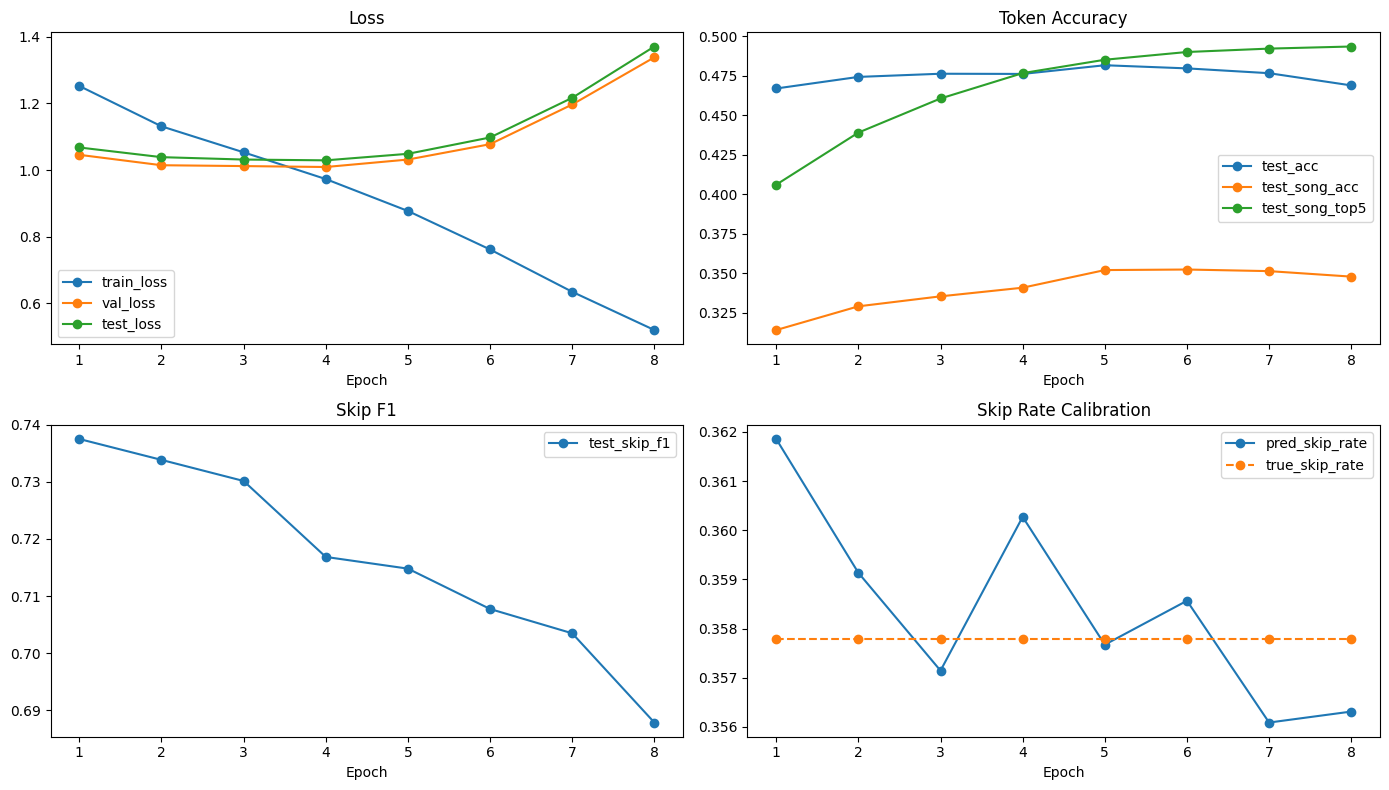

In [12]:
# Curves
if len(history_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    axes[0, 0].plot(history_df["epoch"], history_df["test_loss"], marker="o", label="test_loss")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend()

    axes[0, 1].plot(history_df["epoch"], history_df["test_acc"], marker="o", label="test_acc")
    axes[0, 1].plot(history_df["epoch"], history_df["test_song_acc"], marker="o", label="test_song_acc")
    axes[0, 1].plot(history_df["epoch"], history_df["test_song_top5"], marker="o", label="test_song_top5")
    axes[0, 1].set_title("Token Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend()

    axes[1, 0].plot(history_df["epoch"], history_df["test_skip_f1"], marker="o", label="test_skip_f1")
    axes[1, 0].set_title("Skip F1")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend()

    axes[1, 1].plot(history_df["epoch"], history_df["test_pred_skip_rate"], marker="o", label="pred_skip_rate")
    axes[1, 1].plot(history_df["epoch"], history_df["test_true_skip_rate"], marker="o", linestyle="--", label="true_skip_rate")
    axes[1, 1].set_title("Skip Rate Calibration")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


Final threshold: 0.6034
Final test metrics:
  loss: 1.3706
  overall_acc: 0.4690
  song_acc: 0.3479
  song_top5_acc: 0.4936
  skip_precision: 0.6893
  skip_recall: 0.6864
  skip_f1: 0.6878
  pred_skip_rate: 0.3563
  true_skip_rate: 0.3578


,model,overall_acc,song_acc,skip_precision,skip_recall,skip_f1,pred_skip_rate,true_skip_rate
0,baseline_always_skip,0.3578,0.0000,0.3578,1.0000,0.5270,1.0000,0.3578
1,baseline_mode_song,0.2293,0.3571,0.0000,0.0000,0.0000,0.0000,0.3578
2,transformer_compound,0.4690,0.3479,0.6893,0.6864,0.6878,0.3563,0.3578


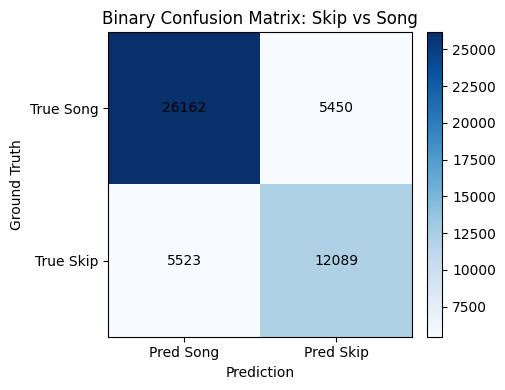

In [13]:
# Final test report with tuned threshold from last epoch
final_threshold = float(history_df.iloc[-1]["threshold"]) if len(history_df) > 0 else 0.5
final_metrics, y_true, pred_song, skip_prob = evaluate_model(model, test_loader, threshold=final_threshold)
y_pred = decode_with_threshold(skip_prob, pred_song, final_threshold)

print("Final threshold:", round(final_threshold, 4))
print("Final test metrics:")
for k in ["loss", "overall_acc", "song_acc", "song_top5_acc", "skip_precision", "skip_recall", "skip_f1", "pred_skip_rate", "true_skip_rate"]:
    print(f"  {k}: {final_metrics[k]:.4f}")

# Baselines for professor presentation
baseline_rows = []

# Baseline 1: always SKIP
pred_all_skip = np.ones_like(y_true)
m_skip = compute_token_metrics(y_true, pred_all_skip)
baseline_rows.append({"model": "baseline_always_skip", **m_skip})

# Baseline 2: always most frequent song token from train targets
song_targets_train = y_train[y_train != 1]
mode_song_token = int(pd.Series(song_targets_train).value_counts().index[0]) if len(song_targets_train) > 0 else 2
pred_mode_song = np.full_like(y_true, mode_song_token)
m_mode = compute_token_metrics(y_true, pred_mode_song)
baseline_rows.append({"model": "baseline_mode_song", **m_mode})

# Model row
baseline_rows.append({"model": "transformer_compound", **compute_token_metrics(y_true, y_pred)})

report_df = pd.DataFrame(baseline_rows)
show_cols = [
    "model", "overall_acc", "song_acc", "skip_precision", "skip_recall", "skip_f1", "pred_skip_rate", "true_skip_rate"
]
display(report_df[show_cols].round(4))

# Binary confusion matrix: skip vs song
cm = confusion_matrix((y_true == 1).astype(int), (y_pred == 1).astype(int), labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred Song", "Pred Skip"])
ax.set_yticks([0, 1], labels=["True Song", "True Skip"])
ax.set_title("Binary Confusion Matrix: Skip vs Song")
ax.set_xlabel("Prediction")
ax.set_ylabel("Ground Truth")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Notes

- If you need faster iteration, set `CONFIG["max_sessions"]` to a smaller value (e.g., `3000`).
- If skip prediction is still weak, adjust `CONFIG["skip_loss_weight"]` modestly (start around `6.0`, then try `4.0` or `8.0`).


## Direct Per-Track Skip Objective (Clean Experiment)

This section trains a fresh model with **true per-track skip labels** (sequence labeling style):

- Input = history up to (but not including) the current track event
- Target = whether the **current track** is skipped

This avoids using the proxy target `next token == SKIP` and aligns training directly with skip prediction.

In [14]:
# Build per-track skip-labeled examples (direct objective)

def build_skip_examples_from_events(df, session_col, position_col, max_seq_len, pad_token_id=0):
    X_list, A_list, y_skip_list, y_song_list = [], [], [], []

    grouped = df.sort_values([session_col, position_col]).groupby(session_col, sort=False)

    for _, grp in grouped:
        history_tokens = []
        song_arr = grp["song_idx"].to_numpy(np.int64)
        skip_arr = grp["skip"].to_numpy(np.int64)

        for i in range(len(grp)):
            song_token = int(song_arr[i]) + 2
            sk = int(skip_arr[i])

            # Predict skip for current track from prior history only.
            if len(history_tokens) > 0:
                hist = history_tokens[-max_seq_len:]
                L = len(hist)
                x = np.full((max_seq_len,), pad_token_id, dtype=np.int64)
                a = np.zeros((max_seq_len,), dtype=np.int64)
                x[:L] = np.array(hist, dtype=np.int64)
                a[:L] = 1

                X_list.append(x)
                A_list.append(a)
                y_skip_list.append(sk)
                y_song_list.append(song_token)

            # Update history with the realized event representation.
            history_tokens.append(song_token)
            if sk == 1:
                history_tokens.append(1)

    X = np.stack(X_list) if len(X_list) > 0 else np.zeros((0, max_seq_len), dtype=np.int64)
    A = np.stack(A_list) if len(A_list) > 0 else np.zeros((0, max_seq_len), dtype=np.int64)
    y_skip = np.asarray(y_skip_list, dtype=np.int64)
    y_song = np.asarray(y_song_list, dtype=np.int64)
    return X, A, y_skip, y_song


Xtr_s, Atr_s, ytr_skip, ytr_song = build_skip_examples_from_events(
    train_enc, CONFIG["session_col"], CONFIG["position_col"], CONFIG["max_seq_len"]
)
Xva_s, Ava_s, yva_skip, yva_song = build_skip_examples_from_events(
    val_enc, CONFIG["session_col"], CONFIG["position_col"], CONFIG["max_seq_len"]
)
Xte_s, Ate_s, yte_skip, yte_song = build_skip_examples_from_events(
    test_enc, CONFIG["session_col"], CONFIG["position_col"], CONFIG["max_seq_len"]
)


class SkipSeqDataset(Dataset):
    def __init__(self, X, A, y_skip, y_song):
        self.X = torch.from_numpy(X).long()
        self.A = torch.from_numpy(A).long()
        self.y_skip = torch.from_numpy(y_skip).float()
        self.y_song = torch.from_numpy(y_song).long()

    def __len__(self):
        return self.y_skip.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.A[idx], self.y_skip[idx], self.y_song[idx]


train_skip_ds = SkipSeqDataset(Xtr_s, Atr_s, ytr_skip, ytr_song)
val_skip_ds = SkipSeqDataset(Xva_s, Ava_s, yva_skip, yva_song)
test_skip_ds = SkipSeqDataset(Xte_s, Ate_s, yte_skip, yte_song)

train_skip_loader = DataLoader(train_skip_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_skip_loader = DataLoader(val_skip_ds, batch_size=CONFIG["batch_size"], shuffle=False)
test_skip_loader = DataLoader(test_skip_ds, batch_size=CONFIG["batch_size"], shuffle=False)

print("Direct-skip examples | Train:", len(ytr_skip), "Val:", len(yva_skip), "Test:", len(yte_skip))
print("Direct-skip rates   | Train:", float(np.mean(ytr_skip)), "Val:", float(np.mean(yva_skip)), "Test:", float(np.mean(yte_skip)))

Direct-skip examples | Train: 110297 Val: 15971 Test: 31612
Direct-skip rates   | Train: 0.5248646835362702 Val: 0.5186901258531088 Test: 0.5338479058585347


In [15]:
# Train a fresh model for direct skip prediction

model_skip = CompoundTokenTransformer(
    song_vocab_size=len(song_to_idx) + 1,
    token_to_song_feature=token_to_song_feature,
    token_to_aux_num=token_to_aux_num,
    token_to_aux_cat=token_to_aux_cat,
    aux_cat_vocab_sizes=aux_cat_vocab_sizes,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_layers=CONFIG["num_layers"],
    ff_dim=CONFIG["ff_dim"],
    max_seq_len=CONFIG["max_seq_len"],
    activation=CONFIG["activation"],
    use_bias=CONFIG["use_bias"],
).to(DEVICE)

train_skip_rate = float(np.mean(ytr_skip))
pos_weight = (1.0 - train_skip_rate) / max(train_skip_rate, 1e-6)
skip_loss_direct = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=DEVICE)
)
optimizer_skip = torch.optim.AdamW(
    model_skip.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)
print(f"Direct skip training | pos_weight={pos_weight:.4f}")


def compute_skip_metrics(y_true, skip_prob, threshold=0.5):
    y_pred = (skip_prob >= threshold).astype(np.int64)
    acc = float(accuracy_score(y_true, y_pred))
    sp, sr, sf1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {
        "acc": acc,
        "skip_precision": float(sp),
        "skip_recall": float(sr),
        "skip_f1": float(sf1),
        "pred_skip_rate": float(np.mean(y_pred)),
        "true_skip_rate": float(np.mean(y_true)),
    }


def tune_skip_threshold(y_true, skip_prob, threshold_grid):
    target_rate = float(np.mean(y_true))
    candidates = [float(t) for t in threshold_grid]
    if len(skip_prob) > 0:
        q = max(0.0, min(1.0, 1.0 - target_rate))
        candidates.append(float(np.quantile(skip_prob, q)))
        candidates.extend([0.0, 1.0])
    candidates = sorted(set(candidates))

    best_thr, best_score, best_m = 0.5, -1e9, None
    for thr in candidates:
        m = compute_skip_metrics(y_true, skip_prob, threshold=float(thr))
        rate_penalty = abs(m["pred_skip_rate"] - target_rate)
        score = m["skip_f1"] - 0.10 * rate_penalty
        if score > best_score:
            best_thr, best_score, best_m = float(thr), score, m
    return best_thr, best_m


def evaluate_skip_direct(model, loader, threshold=0.5):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    seen = 0

    with torch.no_grad():
        for x, a, y_skip, _ in loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y_skip = y_skip.to(DEVICE)

            _, skip_logit = model(x, a)
            skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)
            loss = skip_loss_direct(skip_logit, y_skip)

            if torch.isfinite(loss):
                bs = y_skip.size(0)
                total_loss += float(loss.item()) * bs
                seen += bs

            prob = torch.sigmoid(skip_logit).cpu().numpy()
            ys.append(y_skip.cpu().numpy().astype(np.int64))
            probs.append(prob)

    y_true = np.concatenate(ys)
    skip_prob = np.concatenate(probs)
    metrics = compute_skip_metrics(y_true, skip_prob, threshold=threshold)
    metrics["loss"] = total_loss / max(seen, 1)
    metrics["skip_prob_mean"] = float(np.mean(skip_prob))
    metrics["skip_prob_std"] = float(np.std(skip_prob))
    return metrics, y_true, skip_prob


history_skip_direct = []
for epoch in range(1, CONFIG["epochs"] + 1):
    model_skip.train()
    running = 0.0
    seen = 0

    pbar = tqdm(train_skip_loader, desc=f"DirectSkip Epoch {epoch}/{CONFIG['epochs']}", leave=True, dynamic_ncols=True)
    for x, a, y_skip, _ in pbar:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        y_skip = y_skip.to(DEVICE)

        optimizer_skip.zero_grad()
        _, skip_logit = model_skip(x, a)
        skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

        loss = skip_loss_direct(skip_logit, y_skip)
        if not torch.isfinite(loss):
            pbar.set_postfix({"batch_loss": "nan/inf"})
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model_skip.parameters(), 1.0)
        optimizer_skip.step()

        bs = y_skip.size(0)
        running += float(loss.item()) * bs
        seen += bs
        pbar.set_postfix({"batch_loss": f"{float(loss.item()):.4f}"})

    train_loss = running / max(seen, 1)

    val_raw, y_val_true, val_skip_prob = evaluate_skip_direct(model_skip, val_skip_loader, threshold=0.5)
    tuned_thr, _ = tune_skip_threshold(y_val_true, val_skip_prob, CONFIG["threshold_grid"])

    val_metrics, _, _ = evaluate_skip_direct(model_skip, val_skip_loader, threshold=tuned_thr)
    test_metrics, _, _ = evaluate_skip_direct(model_skip, test_skip_loader, threshold=tuned_thr)

    row = {
        "epoch": epoch,
        "threshold": tuned_thr,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "test_loss": test_metrics["loss"],
        "val_skip_f1": val_metrics["skip_f1"],
        "test_skip_f1": test_metrics["skip_f1"],
        "val_skip_precision": val_metrics["skip_precision"],
        "test_skip_precision": test_metrics["skip_precision"],
        "val_skip_recall": val_metrics["skip_recall"],
        "test_skip_recall": test_metrics["skip_recall"],
        "test_pred_skip_rate": test_metrics["pred_skip_rate"],
        "test_true_skip_rate": test_metrics["true_skip_rate"],
    }
    history_skip_direct.append(row)

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | test_loss={test_metrics['loss']:.4f} | "
        f"skip_F1={test_metrics['skip_f1']:.4f} | "
        f"P={test_metrics['skip_precision']:.4f} | R={test_metrics['skip_recall']:.4f} | "
        f"skip_rate_pred={test_metrics['pred_skip_rate']:.4f}"
    )

history_skip_direct_df = pd.DataFrame(history_skip_direct)
display(history_skip_direct_df.round(4))

Direct skip training | pos_weight=0.9053


DirectSkip Epoch 1/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.5423 | val_loss=0.5292 | test_loss=0.5458 | skip_F1=0.7474 | P=0.7462 | R=0.7486 | skip_rate_pred=0.5356


DirectSkip Epoch 2/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.5316 | val_loss=0.5303 | test_loss=0.5431 | skip_F1=0.7496 | P=0.7402 | R=0.7593 | skip_rate_pred=0.5476


...

DirectSkip Epoch 7/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 07 | train_loss=0.4346 | val_loss=0.5925 | test_loss=0.6101 | skip_F1=0.7315 | P=0.6972 | R=0.7694 | skip_rate_pred=0.5891


DirectSkip Epoch 8/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 08 | train_loss=0.3688 | val_loss=0.6539 | test_loss=0.6702 | skip_F1=0.7173 | P=0.6756 | R=0.7645 | skip_rate_pred=0.6040


,epoch,threshold,train_loss,val_loss,test_loss,val_skip_f1,test_skip_f1,val_skip_precision,test_skip_precision,val_skip_recall,test_skip_recall,test_pred_skip_rate,test_true_skip_rate
0,1,0.45,0.5423,0.5292,0.5458,0.7547,0.7474,0.7526,0.7462,0.7568,0.7486,0.5356,0.5338
1,2,0.45,0.5316,0.5303,0.5431,0.7556,0.7496,0.7450,0.7402,0.7665,0.7593,0.5476,0.5338
2,3,0.37,0.5258,0.5326,0.5480,0.7542,0.7487,0.7381,0.7326,0.7710,0.7656,0.5579,0.5338
3,4,0.45,0.5177,0.5336,0.5485,0.7525,0.7466,0.7479,0.7416,0.7572,0.7517,0.5411,0.5338
4,5,0.46,0.5051,0.5441,0.5564,0.7437,0.7413,0.7392,0.7339,0.7482,0.7489,0.5447,0.5338
5,6,0.38,0.4795,0.5537,0.5674,0.7412,0.7374,0.7088,0.7011,0.7768,0.7776,0.5921,0.5338
6,7,0.39,0.4346,0.5925,0.6101,0.7354,0.7315,0.7045,0.6972,0.7692,0.7694,0.5891,0.5338
7,8,0.37,0.3688,0.6539,0.6702,0.7203,0.7173,0.6836,0.6756,0.7612,0.7645,0.6040,0.5338


Best epoch (by val_skip_f1): 2
Best threshold: 0.45

Final direct-skip test metrics:
  loss: 0.6702
  acc: 0.6808
  skip_precision: 0.6937
  skip_recall: 0.7200
  skip_f1: 0.7066
  pred_skip_rate: 0.5541
  true_skip_rate: 0.5338

Baselines (direct-skip labels):
  always_skip   -> F1=0.6961 P=0.5338 R=1.0000
  always_noskip -> F1=0.0000 P=0.0000 R=0.0000


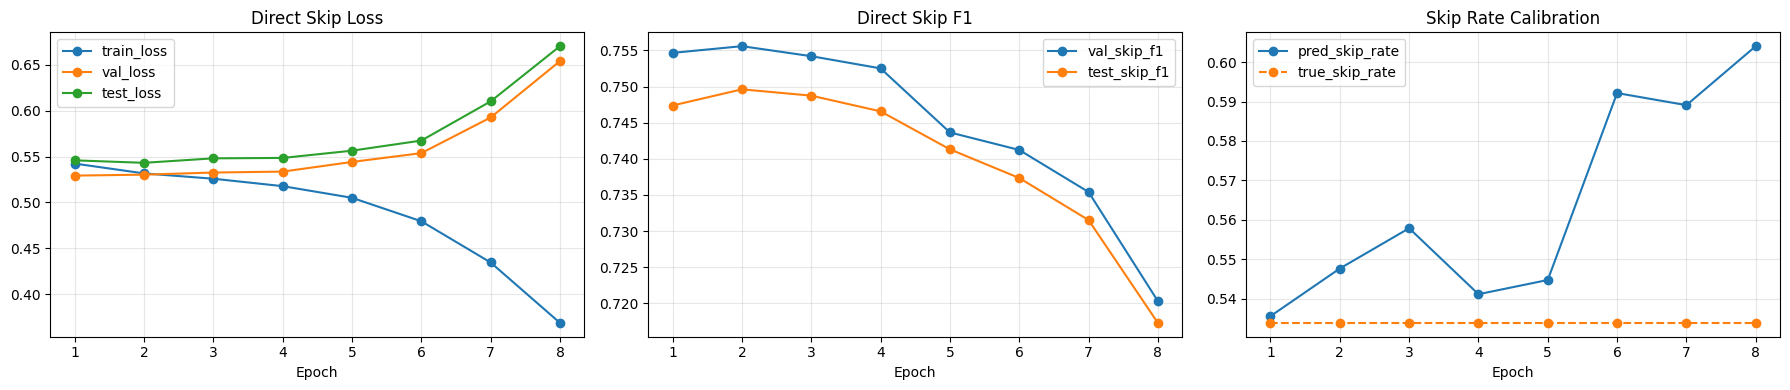


Confusion matrix [rows=true 0/1, cols=pred 0/1]:
[[ 9372  5364]
 [ 4725 12151]]


In [16]:
# Direct-skip final report and diagnostics

if len(history_skip_direct_df) == 0:
    raise RuntimeError("No direct-skip training history found.")

best_idx = int(history_skip_direct_df["val_skip_f1"].idxmax())
best_row = history_skip_direct_df.iloc[best_idx]
best_thr = float(best_row["threshold"])

final_metrics_direct, y_true_direct, skip_prob_direct = evaluate_skip_direct(
    model_skip, test_skip_loader, threshold=best_thr
)
y_pred_direct = (skip_prob_direct >= best_thr).astype(np.int64)

print("Best epoch (by val_skip_f1):", int(best_row["epoch"]))
print("Best threshold:", round(best_thr, 4))
print("\nFinal direct-skip test metrics:")
for k in ["loss", "acc", "skip_precision", "skip_recall", "skip_f1", "pred_skip_rate", "true_skip_rate"]:
    print(f"  {k}: {final_metrics_direct[k]:.4f}")

# Baselines
pred_all_skip = np.ones_like(y_true_direct)
pred_all_noskip = np.zeros_like(y_true_direct)

m_all_skip = compute_skip_metrics(y_true_direct, pred_all_skip.astype(np.float32), threshold=0.5)
m_all_noskip = compute_skip_metrics(y_true_direct, pred_all_noskip.astype(np.float32), threshold=0.5)

print("\nBaselines (direct-skip labels):")
print("  always_skip   -> F1={:.4f} P={:.4f} R={:.4f}".format(m_all_skip["skip_f1"], m_all_skip["skip_precision"], m_all_skip["skip_recall"]))
print("  always_noskip -> F1={:.4f} P={:.4f} R={:.4f}".format(m_all_noskip["skip_f1"], m_all_noskip["skip_precision"], m_all_noskip["skip_recall"]))

# Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_skip_direct_df["epoch"], history_skip_direct_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(history_skip_direct_df["epoch"], history_skip_direct_df["val_loss"], marker="o", label="val_loss")
axes[0].plot(history_skip_direct_df["epoch"], history_skip_direct_df["test_loss"], marker="o", label="test_loss")
axes[0].set_title("Direct Skip Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_skip_direct_df["epoch"], history_skip_direct_df["val_skip_f1"], marker="o", label="val_skip_f1")
axes[1].plot(history_skip_direct_df["epoch"], history_skip_direct_df["test_skip_f1"], marker="o", label="test_skip_f1")
axes[1].set_title("Direct Skip F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history_skip_direct_df["epoch"], history_skip_direct_df["test_pred_skip_rate"], marker="o", label="pred_skip_rate")
axes[2].plot(history_skip_direct_df["epoch"], history_skip_direct_df["test_true_skip_rate"], marker="o", linestyle="--", label="true_skip_rate")
axes[2].set_title("Skip Rate Calibration")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

cm_direct = confusion_matrix(y_true_direct, y_pred_direct, labels=[0, 1])
print("\nConfusion matrix [rows=true 0/1, cols=pred 0/1]:")
print(cm_direct)

## Direct Skip + Current Event Context (Next Upgrade)

This variant keeps direct per-track skip labels and adds **current-event predictors**:

- current song token embedding
- current row numeric context features
- current row categorical context features

The history encoder still uses prior session history only.

In [17]:
# Build direct-skip examples with current-event context features

def build_skip_examples_with_event_context(
    df,
    session_col,
    position_col,
    max_seq_len,
    aux_num_cols,
    aux_cat_cols,
    aux_num_mean,
    aux_num_std,
    aux_cat_to_idx,
    pad_token_id=0,
):
    X_list, A_list = [], []
    y_skip_list, curr_song_token_list = [], []
    curr_num_list, curr_cat_list = [], []

    grouped = df.sort_values([session_col, position_col]).groupby(session_col, sort=False)

    for _, grp in grouped:
        history_tokens = []

        song_arr = grp["song_idx"].to_numpy(np.int64)
        skip_arr = grp["skip"].to_numpy(np.int64)

        if len(aux_num_cols) > 0:
            num_df = grp[aux_num_cols].copy()
            num_df = num_df.fillna(aux_num_mean)
            num_df = (num_df - aux_num_mean) / aux_num_std
            num_mat = num_df.astype(np.float32).to_numpy()
        else:
            num_mat = np.zeros((len(grp), 0), dtype=np.float32)

        if len(aux_cat_cols) > 0:
            cat_mat = np.zeros((len(grp), len(aux_cat_cols)), dtype=np.int64)
            for j, c in enumerate(aux_cat_cols):
                vocab = aux_cat_to_idx[c]
                vals = grp[c].astype(str).fillna("<UNK>").to_list()
                cat_mat[:, j] = np.asarray([vocab.get(v, vocab["<UNK>"]) for v in vals], dtype=np.int64)
        else:
            cat_mat = np.zeros((len(grp), 0), dtype=np.int64)

        for i in range(len(grp)):
            song_token = int(song_arr[i]) + 2
            sk = int(skip_arr[i])

            if len(history_tokens) > 0:
                hist = history_tokens[-max_seq_len:]
                L = len(hist)
                x = np.full((max_seq_len,), pad_token_id, dtype=np.int64)
                a = np.zeros((max_seq_len,), dtype=np.int64)
                x[:L] = np.array(hist, dtype=np.int64)
                a[:L] = 1

                X_list.append(x)
                A_list.append(a)
                y_skip_list.append(sk)
                curr_song_token_list.append(song_token)
                curr_num_list.append(num_mat[i])
                curr_cat_list.append(cat_mat[i])

            history_tokens.append(song_token)
            if sk == 1:
                history_tokens.append(1)

    X = np.stack(X_list) if len(X_list) > 0 else np.zeros((0, max_seq_len), dtype=np.int64)
    A = np.stack(A_list) if len(A_list) > 0 else np.zeros((0, max_seq_len), dtype=np.int64)
    y_skip = np.asarray(y_skip_list, dtype=np.int64)
    curr_song_token = np.asarray(curr_song_token_list, dtype=np.int64)

    curr_num = np.stack(curr_num_list) if len(curr_num_list) > 0 else np.zeros((0, len(aux_num_cols)), dtype=np.float32)
    curr_cat = np.stack(curr_cat_list) if len(curr_cat_list) > 0 else np.zeros((0, len(aux_cat_cols)), dtype=np.int64)

    return X, A, y_skip, curr_song_token, curr_num, curr_cat


class SkipContextDataset(Dataset):
    def __init__(self, X, A, y_skip, curr_song_token, curr_num, curr_cat):
        self.X = torch.from_numpy(X).long()
        self.A = torch.from_numpy(A).long()
        self.y_skip = torch.from_numpy(y_skip).float()
        self.curr_song_token = torch.from_numpy(curr_song_token).long()
        self.curr_num = torch.from_numpy(curr_num).float()
        self.curr_cat = torch.from_numpy(curr_cat).long()

    def __len__(self):
        return self.y_skip.size(0)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.A[idx],
            self.y_skip[idx],
            self.curr_song_token[idx],
            self.curr_num[idx],
            self.curr_cat[idx],
        )


Xtr_c, Atr_c, ytr_c, songtok_tr_c, num_tr_c, cat_tr_c = build_skip_examples_with_event_context(
    train_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
    CONFIG["max_seq_len"],
    aux_num_cols,
    aux_cat_cols,
    aux_num_mean,
    aux_num_std,
    aux_cat_to_idx,
)
Xva_c, Ava_c, yva_c, songtok_va_c, num_va_c, cat_va_c = build_skip_examples_with_event_context(
    val_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
    CONFIG["max_seq_len"],
    aux_num_cols,
    aux_cat_cols,
    aux_num_mean,
    aux_num_std,
    aux_cat_to_idx,
)
Xte_c, Ate_c, yte_c, songtok_te_c, num_te_c, cat_te_c = build_skip_examples_with_event_context(
    test_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
    CONFIG["max_seq_len"],
    aux_num_cols,
    aux_cat_cols,
    aux_num_mean,
    aux_num_std,
    aux_cat_to_idx,
)

train_ctx_ds = SkipContextDataset(Xtr_c, Atr_c, ytr_c, songtok_tr_c, num_tr_c, cat_tr_c)
val_ctx_ds = SkipContextDataset(Xva_c, Ava_c, yva_c, songtok_va_c, num_va_c, cat_va_c)
test_ctx_ds = SkipContextDataset(Xte_c, Ate_c, yte_c, songtok_te_c, num_te_c, cat_te_c)

train_ctx_loader = DataLoader(train_ctx_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_ctx_loader = DataLoader(val_ctx_ds, batch_size=CONFIG["batch_size"], shuffle=False)
test_ctx_loader = DataLoader(test_ctx_ds, batch_size=CONFIG["batch_size"], shuffle=False)

print("Context-direct examples | Train:", len(ytr_c), "Val:", len(yva_c), "Test:", len(yte_c))
print("Train skip rate:", float(np.mean(ytr_c)))
print("Current event numeric dims:", num_tr_c.shape[1], "| categorical dims:", cat_tr_c.shape[1])

Context-direct examples | Train: 110297 Val: 15971 Test: 31612
Train skip rate: 0.5248646835362702
Current event numeric dims: 30 | categorical dims: 12


In [18]:
# Model variant: history encoder + current-event context fusion for skip prediction

class DirectSkipWithEventContext(nn.Module):
    def __init__(self, base_model, event_num_dim, event_cat_vocab_sizes, use_bias=False):
        super().__init__()
        self.base = base_model
        d_model = base_model.song_emb.embedding_dim

        self.event_num_dim = int(event_num_dim)
        if self.event_num_dim > 0:
            self.event_num_proj = nn.Linear(self.event_num_dim, d_model, bias=use_bias)
        else:
            self.event_num_proj = None

        self.event_cat_embs = nn.ModuleList([nn.Embedding(v, d_model) for v in event_cat_vocab_sizes])

        self.fuse = nn.Linear(3 * d_model, d_model, bias=use_bias)
        self.skip_out = nn.Linear(d_model, 1, bias=use_bias)

    def embed_song_token(self, token_ids):
        # token_ids shape: [B]
        token_ids = token_ids.long()
        song_ids = self.base.token_to_song_feature[token_ids]
        x_song = self.base.song_emb(song_ids)

        if self.base.num_aux_num > 0:
            x_song = x_song + self.base.aux_num_proj(self.base.token_to_aux_num[token_ids])

        if self.base.num_aux_cat > 0:
            x_cat = self.base.token_to_aux_cat[token_ids]
            for j in range(self.base.num_aux_cat):
                x_song = x_song + self.base.aux_cat_embs[j](x_cat[:, j])

        skip_mask = (token_ids == self.base.skip_token_id)
        if skip_mask.any():
            x_song = x_song.clone()
            x_song[skip_mask] = self.base.skip_emb.view(1, -1)

        return x_song

    def embed_event_context(self, event_num, event_cat):
        # event_num: [B, E_num], event_cat: [B, E_cat]
        B = event_cat.shape[0] if event_cat.ndim == 2 else event_num.shape[0]
        d_model = self.base.song_emb.embedding_dim
        x = torch.zeros((B, d_model), device=event_num.device)

        if self.event_num_proj is not None:
            x = x + self.event_num_proj(event_num)

        if len(self.event_cat_embs) > 0:
            for j, emb in enumerate(self.event_cat_embs):
                x = x + emb(event_cat[:, j])

        return x

    def forward(self, token_ids, attention_mask, curr_song_token, event_num, event_cat):
        h_hist = self.base.encode_last(token_ids, attention_mask)
        h_song = self.embed_song_token(curr_song_token)
        h_evt = self.embed_event_context(event_num, event_cat)

        h = torch.cat([h_hist, h_song, h_evt], dim=1)
        h = torch.nn.functional.silu(self.fuse(h))
        skip_logit = self.skip_out(h).squeeze(1)
        return skip_logit


base_ctx_model = CompoundTokenTransformer(
    song_vocab_size=len(song_to_idx) + 1,
    token_to_song_feature=token_to_song_feature,
    token_to_aux_num=token_to_aux_num,
    token_to_aux_cat=token_to_aux_cat,
    aux_cat_vocab_sizes=aux_cat_vocab_sizes,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_layers=CONFIG["num_layers"],
    ff_dim=CONFIG["ff_dim"],
    max_seq_len=CONFIG["max_seq_len"],
    activation=CONFIG["activation"],
    use_bias=CONFIG["use_bias"],
).to(DEVICE)

model_ctx = DirectSkipWithEventContext(
    base_model=base_ctx_model,
    event_num_dim=len(aux_num_cols),
    event_cat_vocab_sizes=[len(aux_cat_to_idx[c]) for c in aux_cat_cols],
    use_bias=CONFIG["use_bias"],
).to(DEVICE)

train_skip_rate_ctx = float(np.mean(ytr_c))
pos_weight_ctx = (1.0 - train_skip_rate_ctx) / max(train_skip_rate_ctx, 1e-6)
skip_loss_ctx = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_ctx, dtype=torch.float32, device=DEVICE))
optimizer_ctx = torch.optim.AdamW(model_ctx.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

print(f"Context model ready | pos_weight={pos_weight_ctx:.4f}")

Context model ready | pos_weight=0.9053


Baseline skip_f1 (threshold=0.5000): 0.3804

Top 20 features by permutation importance (delta skip_f1):


,feature,feature_type,baseline_f1,shuffled_f1,delta_f1
0,cat::hist_user_behavior_reason_start,categorical,0.3804,0.3623,0.0181
1,cat::hist_user_behavior_is_shuffle,categorical,0.3804,0.3651,0.0153
2,cat::no_pause_before_play,categorical,0.3804,0.3679,0.0125
3,num::acoustic_vector_7,numeric,0.3804,0.3768,0.0036
4,cat::premium,categorical,0.3804,0.3777,0.0027
5,cat::mode,categorical,0.3804,0.3785,0.0019
6,cat::short_pause_before_play,categorical,0.3804,0.3790,0.0014
7,num::session_length,numeric,0.3804,0.3791,0.0013
8,num::hour_of_day,numeric,0.3804,0.3792,0.0012
9,num::energy,numeric,0.3804,0.3796,0.0008


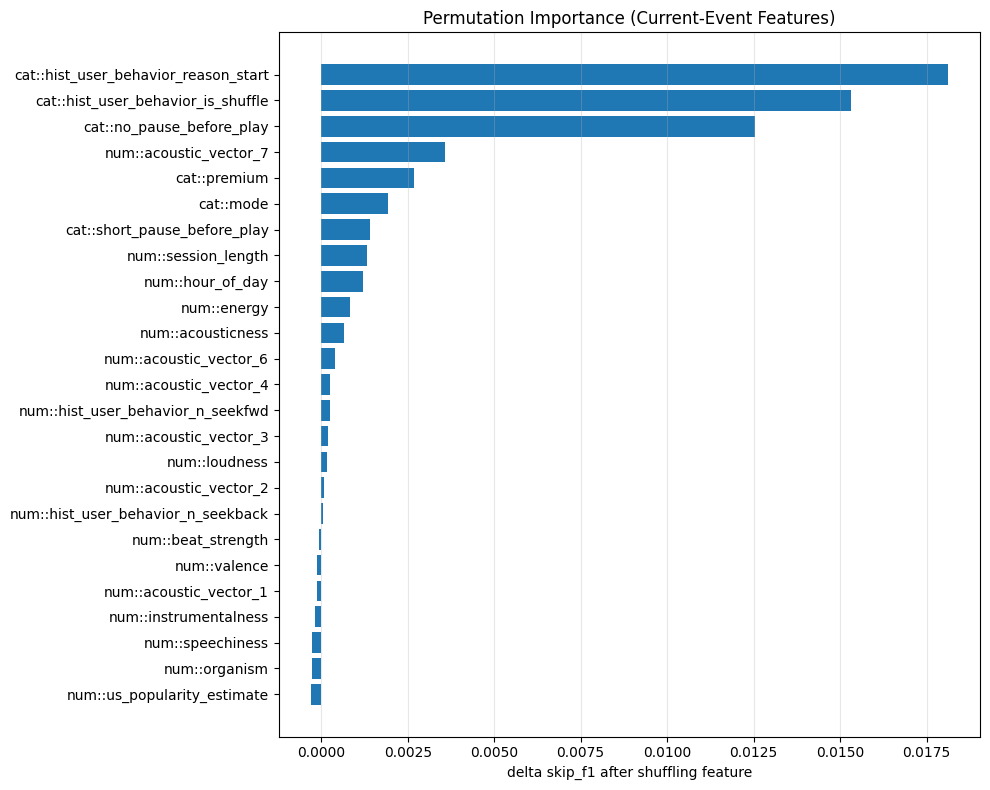

In [19]:
# Permutation importance for current-event features (context model)

if "model_ctx" not in globals() or "test_ctx_ds" not in globals():
    raise RuntimeError("Run the context-model training section first.")

if "best_thr_ctx" not in globals():
    best_thr_ctx = 0.5


def _predict_skip_probs_ctx(model, X, A, curr_song_tok, curr_num, curr_cat, batch_size=1024):
    model.eval()
    probs = []
    n = X.shape[0]
    with torch.no_grad():
        for i in range(0, n, batch_size):
            j = min(i + batch_size, n)
            xb = X[i:j].to(DEVICE)
            ab = A[i:j].to(DEVICE)
            sb = curr_song_tok[i:j].to(DEVICE)
            nb = curr_num[i:j].to(DEVICE)
            cb = curr_cat[i:j].to(DEVICE)

            logit = model(xb, ab, sb, nb, cb)
            prob = torch.sigmoid(logit).cpu().numpy()
            probs.append(prob)

    return np.concatenate(probs)


# Materialize test tensors once for fast repeated permutations
X_base = test_ctx_ds.X.clone()
A_base = test_ctx_ds.A.clone()
y_base = test_ctx_ds.y_skip.cpu().numpy().astype(np.int64)
song_base = test_ctx_ds.curr_song_token.clone()
num_base = test_ctx_ds.curr_num.clone()
cat_base = test_ctx_ds.curr_cat.clone()

# Baseline
base_prob = _predict_skip_probs_ctx(model_ctx, X_base, A_base, song_base, num_base, cat_base)
base_metrics = compute_skip_metrics(y_base, base_prob, threshold=float(best_thr_ctx))
base_f1 = base_metrics["skip_f1"]
print(f"Baseline skip_f1 (threshold={best_thr_ctx:.4f}): {base_f1:.4f}")

rng = np.random.default_rng(42)
rows = []

# Numeric feature permutation
for j, feat in enumerate(aux_num_cols):
    num_perm = num_base.clone()
    idx = torch.from_numpy(rng.permutation(num_perm.shape[0]))
    num_perm[:, j] = num_perm[idx, j]

    prob = _predict_skip_probs_ctx(model_ctx, X_base, A_base, song_base, num_perm, cat_base)
    m = compute_skip_metrics(y_base, prob, threshold=float(best_thr_ctx))
    rows.append({
        "feature": f"num::{feat}",
        "feature_type": "numeric",
        "baseline_f1": float(base_f1),
        "shuffled_f1": float(m["skip_f1"]),
        "delta_f1": float(base_f1 - m["skip_f1"]),
    })

# Categorical feature permutation
for j, feat in enumerate(aux_cat_cols):
    cat_perm = cat_base.clone()
    idx = torch.from_numpy(rng.permutation(cat_perm.shape[0]))
    cat_perm[:, j] = cat_perm[idx, j]

    prob = _predict_skip_probs_ctx(model_ctx, X_base, A_base, song_base, num_base, cat_perm)
    m = compute_skip_metrics(y_base, prob, threshold=float(best_thr_ctx))
    rows.append({
        "feature": f"cat::{feat}",
        "feature_type": "categorical",
        "baseline_f1": float(base_f1),
        "shuffled_f1": float(m["skip_f1"]),
        "delta_f1": float(base_f1 - m["skip_f1"]),
    })

imp_df = pd.DataFrame(rows).sort_values("delta_f1", ascending=False).reset_index(drop=True)
print("\nTop 20 features by permutation importance (delta skip_f1):")
display(imp_df.head(20).round(4))

# Plot top features
topn = min(25, len(imp_df))
plot_df = imp_df.head(topn).iloc[::-1]
plt.figure(figsize=(10, max(6, 0.32 * topn)))
plt.barh(plot_df["feature"], plot_df["delta_f1"])
plt.xlabel("delta skip_f1 after shuffling feature")
plt.title("Permutation Importance (Current-Event Features)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Train + evaluate context-fused direct skip model

def evaluate_ctx(model, loader, threshold=0.5):
    model.eval()
    ys, probs = [], []
    total_loss, seen = 0.0, 0

    with torch.no_grad():
        for x, a, y_skip, curr_song_tok, curr_num, curr_cat in loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y_skip = y_skip.to(DEVICE)
            curr_song_tok = curr_song_tok.to(DEVICE)
            curr_num = curr_num.to(DEVICE)
            curr_cat = curr_cat.to(DEVICE)

            skip_logit = model(x, a, curr_song_tok, curr_num, curr_cat)
            skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

            loss = skip_loss_ctx(skip_logit, y_skip)
            if torch.isfinite(loss):
                bs = y_skip.size(0)
                total_loss += float(loss.item()) * bs
                seen += bs

            prob = torch.sigmoid(skip_logit).cpu().numpy()
            ys.append(y_skip.cpu().numpy().astype(np.int64))
            probs.append(prob)

    y_true = np.concatenate(ys)
    skip_prob = np.concatenate(probs)

    m = compute_skip_metrics(y_true, skip_prob, threshold=threshold)
    m["loss"] = total_loss / max(seen, 1)
    m["skip_prob_mean"] = float(np.mean(skip_prob))
    m["skip_prob_std"] = float(np.std(skip_prob))
    return m, y_true, skip_prob


history_ctx = []
for epoch in range(1, CONFIG["epochs"] + 1):
    model_ctx.train()
    running = 0.0
    seen = 0

    pbar = tqdm(train_ctx_loader, desc=f"CtxSkip Epoch {epoch}/{CONFIG['epochs']}", leave=True, dynamic_ncols=True)
    for x, a, y_skip, curr_song_tok, curr_num, curr_cat in pbar:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        y_skip = y_skip.to(DEVICE)
        curr_song_tok = curr_song_tok.to(DEVICE)
        curr_num = curr_num.to(DEVICE)
        curr_cat = curr_cat.to(DEVICE)

        optimizer_ctx.zero_grad()
        skip_logit = model_ctx(x, a, curr_song_tok, curr_num, curr_cat)
        skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

        loss = skip_loss_ctx(skip_logit, y_skip)
        if not torch.isfinite(loss):
            pbar.set_postfix({"batch_loss": "nan/inf"})
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model_ctx.parameters(), 1.0)
        optimizer_ctx.step()

        bs = y_skip.size(0)
        running += float(loss.item()) * bs
        seen += bs
        pbar.set_postfix({"batch_loss": f"{float(loss.item()):.4f}"})

    train_loss = running / max(seen, 1)

    val_raw, y_val_ctx, val_prob_ctx = evaluate_ctx(model_ctx, val_ctx_loader, threshold=0.5)
    thr_ctx, _ = tune_skip_threshold(y_val_ctx, val_prob_ctx, CONFIG["threshold_grid"])
    val_m, _, _ = evaluate_ctx(model_ctx, val_ctx_loader, threshold=thr_ctx)
    test_m, _, _ = evaluate_ctx(model_ctx, test_ctx_loader, threshold=thr_ctx)

    row = {
        "epoch": epoch,
        "threshold": thr_ctx,
        "train_loss": train_loss,
        "val_loss": val_m["loss"],
        "test_loss": test_m["loss"],
        "val_skip_f1": val_m["skip_f1"],
        "test_skip_f1": test_m["skip_f1"],
        "val_skip_precision": val_m["skip_precision"],
        "test_skip_precision": test_m["skip_precision"],
        "val_skip_recall": val_m["skip_recall"],
        "test_skip_recall": test_m["skip_recall"],
        "test_pred_skip_rate": test_m["pred_skip_rate"],
        "test_true_skip_rate": test_m["true_skip_rate"],
    }
    history_ctx.append(row)

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_m['loss']:.4f} | test_loss={test_m['loss']:.4f} | "
        f"skip_F1={test_m['skip_f1']:.4f} | P={test_m['skip_precision']:.4f} | R={test_m['skip_recall']:.4f} | "
        f"skip_rate_pred={test_m['pred_skip_rate']:.4f}"
    )

history_ctx_df = pd.DataFrame(history_ctx)
display(history_ctx_df.round(4))

best_idx_ctx = int(history_ctx_df["val_skip_f1"].idxmax())
best_row_ctx = history_ctx_df.iloc[best_idx_ctx]
best_thr_ctx = float(best_row_ctx["threshold"])

final_ctx, y_true_ctx, y_prob_ctx = evaluate_ctx(model_ctx, test_ctx_loader, threshold=best_thr_ctx)
y_pred_ctx = (y_prob_ctx >= best_thr_ctx).astype(np.int64)

print("\nBest context epoch:", int(best_row_ctx["epoch"]), "| threshold:", round(best_thr_ctx, 4))
print("Final context-direct test metrics:")
for k in ["loss", "acc", "skip_precision", "skip_recall", "skip_f1", "pred_skip_rate", "true_skip_rate"]:
    print(f"  {k}: {final_ctx[k]:.4f}")

cm_ctx = confusion_matrix(y_true_ctx, y_pred_ctx, labels=[0, 1])
print("\nConfusion matrix [rows=true 0/1, cols=pred 0/1]:")
print(cm_ctx)

CtxSkip Epoch 1/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2686 | val_loss=0.2412 | test_loss=0.2619 | skip_F1=0.8859 | P=0.8554 | R=0.9186 | skip_rate_pred=0.5733


CtxSkip Epoch 2/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.2496 | val_loss=0.2388 | test_loss=0.2608 | skip_F1=0.8838 | P=0.8591 | R=0.9100 | skip_rate_pred=0.5655


CtxSkip Epoch 3/8:   0%|          | 0/431 [00:00<?, ?it/s]

...

Epoch 07 | train_loss=0.1656 | val_loss=0.2769 | test_loss=0.3054 | skip_F1=0.8824 | P=0.8382 | R=0.9315 | skip_rate_pred=0.5933


CtxSkip Epoch 8/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 08 | train_loss=0.1174 | val_loss=0.3390 | test_loss=0.3701 | skip_F1=0.8820 | P=0.8313 | R=0.9393 | skip_rate_pred=0.6032


,epoch,threshold,train_loss,val_loss,test_loss,val_skip_f1,test_skip_f1,val_skip_precision,test_skip_precision,val_skip_recall,test_skip_recall,test_pred_skip_rate,test_true_skip_rate
0,1,0.51,0.2686,0.2412,0.2619,0.8939,0.8859,0.8674,0.8554,0.9220,0.9186,0.5733,0.5338
1,2,0.49,0.2496,0.2388,0.2608,0.8912,0.8838,0.8712,0.8591,0.9121,0.9100,0.5655,0.5338
2,3,0.56,0.2436,0.2390,0.2593,0.8928,0.8851,0.8745,0.8653,0.9119,0.9057,0.5588,0.5338
3,4,0.46,0.2359,0.2438,0.2627,0.8911,0.8847,0.8698,0.8635,0.9136,0.9070,0.5607,0.5338
4,5,0.48,0.2244,0.2406,0.2640,0.8903,0.8830,0.8739,0.8641,0.9073,0.9027,0.5577,0.5338
5,6,0.39,0.2025,0.2565,0.2805,0.8895,0.8844,0.8560,0.8477,0.9256,0.9243,0.5821,0.5338
6,7,0.40,0.1656,0.2769,0.3054,0.8888,0.8824,0.8477,0.8382,0.9341,0.9315,0.5933,0.5338
7,8,0.34,0.1174,0.3390,0.3701,0.8890,0.8820,0.8390,0.8313,0.9453,0.9393,0.6032,0.5338



Best context epoch: 1 | threshold: 0.51
Final context-direct test metrics:
  loss: 0.3701
  acc: 0.8635
  skip_precision: 0.8487
  skip_recall: 0.9057
  skip_f1: 0.8763
  pred_skip_rate: 0.5697
  true_skip_rate: 0.5338

Confusion matrix [rows=true 0/1, cols=pred 0/1]:
[[12012  2724]
 [ 1591 15285]]


In [21]:
# Inspect examples for hist_user_behavior_reason_end

col = "hist_user_behavior_reason_end"

if col not in events_df.columns:
    print(f"Column not found: {col}")
else:
    print(f"Total rows: {len(events_df)}")
    print("\nValue counts (top 20):")
    display(events_df[col].value_counts(dropna=False).head(20))

    print("\nCross-tab with skip label (row-normalized):")
    xt = pd.crosstab(events_df[col], events_df["skip"], normalize="index")
    xt.columns = [f"skip={c}" for c in xt.columns]
    display(xt.sort_values(by=xt.columns[-1], ascending=False).head(20).round(4))

    cols_to_show = [
        "session_id",
        "session_position",
        "track_id_clean",
        "skip",
        "hist_user_behavior_reason_start",
        "hist_user_behavior_reason_end",
    ]
    cols_to_show = [c for c in cols_to_show if c in events_df.columns]

    print("\nRandom sample rows:")
    display(events_df[cols_to_show].sample(n=min(20, len(events_df)), random_state=42).reset_index(drop=True))

    print("\nExamples where reason_end suggests completion:")
    done_mask = events_df[col].astype(str).str.lower().eq("trackdone")
    display(events_df.loc[done_mask, cols_to_show].head(10).reset_index(drop=True))

    print("\nExamples where reason_end suggests user intervention:")
    user_end_vals = {"fwdbtn", "backbtn", "endplay"}
    user_mask = events_df[col].astype(str).str.lower().isin(user_end_vals)
    display(events_df.loc[user_mask, cols_to_show].head(10).reset_index(drop=True))

Total rows: 167880

Value counts (top 20):


,count
hist_user_behavior_reason_end,
fwdbtn,81389
trackdone,57701
endplay,14823
backbtn,13129
logout,563
remote,267
clickrow,8



Cross-tab with skip label (row-normalized):


,skip=0,skip=1
hist_user_behavior_reason_end,,
clickrow,0.0000,1.0000
backbtn,0.1001,0.8999
fwdbtn,0.1900,0.8100
endplay,0.4228,0.5772
remote,0.5468,0.4532
logout,0.7105,0.2895
trackdone,0.9959,0.0041



Random sample rows:


,session_id,session_position,track_id_clean,skip,hist_user_behavior_reason_start,hist_user_behavior_reason_end
0,0_030ddb51-cf56-41b4-8796-fb01546afc9d,18,t_39a0d705-8d81-460c-b404-521b46b85379,0,fwdbtn,trackdone
1,0_09bbc345-0e87-4366-86b1-50f9adbb2f6f,2,t_ce6cbaa6-9042-44bf-841e-4d53b15e8a68,0,trackdone,trackdone
2,0_0792cde4-90a0-45e9-bf9e-b4f78114f1bf,10,t_68888d19-7be6-4cdc-bcfb-be38431f79d7,1,fwdbtn,fwdbtn
3,0_05b21a48-a1d8-4737-90b8-a06479d678cd,14,t_ee458ff5-68ba-41ee-988f-72b2a2fbcf2c,1,fwdbtn,fwdbtn
4,0_07740856-4003-41fb-b1df-47f55544bd62,2,t_e48890a7-f13b-433a-a2c9-e62e00cc8290,0,trackdone,endplay
5,0_0c494d57-1277-4ea3-83da-10f87abd71df,10,t_d3005f6e-257b-4ade-91d6-434b5e56f28e,1,clickrow,endplay
6,0_00c79d43-301d-4f8d-8e01-c5d15aec76ff,4,t_bc83075d-4228-449a-8344-813dda413432,1,fwdbtn,fwdbtn
7,0_095eee24-9be2-4f6c-bebe-a0046b7b3ea1,20,t_f0037227-bcbe-4c65-a19b-f3972ad572a4,1,fwdbtn,fwdbtn
8,0_02427f3a-0db9-4c7a-bd7a-8f2d800cfa6f,1,t_46e936c7-d072-477f-b845-7fa50011ff68,1,trackdone,fwdbtn
9,0_008129c4-cf1e-404f-b5ff-0e8c48ae947b,4,t_ad51b2a6-3ab1-41aa-b28e-d9385d6165cf,1,fwdbtn,fwdbtn



Examples where reason_end suggests completion:


,session_id,session_position,track_id_clean,skip,hist_user_behavior_reason_start,hist_user_behavior_reason_end
0,0_00006f66-33e5-4de7-a324-2d18e439fc1e,1,t_0479f24c-27d2-46d6-a00c-7ec928f2b539,0,trackdone,trackdone
1,0_00006f66-33e5-4de7-a324-2d18e439fc1e,2,t_9099cd7b-c238-47b7-9381-f23f2c1d1043,0,trackdone,trackdone
2,0_00006f66-33e5-4de7-a324-2d18e439fc1e,3,t_fc5df5ba-5396-49a7-8b29-35d0d28249e0,0,trackdone,trackdone
3,0_00006f66-33e5-4de7-a324-2d18e439fc1e,4,t_23cff8d6-d874-4b20-83dc-94e450e8aa20,0,trackdone,trackdone
4,0_00006f66-33e5-4de7-a324-2d18e439fc1e,5,t_64f3743c-f624-46bb-a579-0f3f9a07a123,0,trackdone,trackdone
5,0_00006f66-33e5-4de7-a324-2d18e439fc1e,14,t_a157ba98-7eae-4e7d-99d5-ed760b2c0978,0,fwdbtn,trackdone
6,0_0000a72b-09ac-412f-b452-9b9e79bded8f,11,t_0b38d601-8996-4aec-843c-74f6d96db1f5,0,backbtn,trackdone
7,0_0000a72b-09ac-412f-b452-9b9e79bded8f,12,t_b269ccd8-9bd6-4554-bb4c-da4f5eba1462,0,trackdone,trackdone
8,0_0000a72b-09ac-412f-b452-9b9e79bded8f,14,t_cb4c7305-2fa2-4681-9778-a27e0969e7af,0,fwdbtn,trackdone
9,0_0000a72b-09ac-412f-b452-9b9e79bded8f,17,t_1321c25e-77ce-46ce-b98b-8ad970684845,0,backbtn,trackdone



Examples where reason_end suggests user intervention:


,session_id,session_position,track_id_clean,skip,hist_user_behavior_reason_start,hist_user_behavior_reason_end
0,0_00006f66-33e5-4de7-a324-2d18e439fc1e,6,t_c815228b-3212-4f9e-9d4f-9cb19b248184,0,trackdone,fwdbtn
1,0_00006f66-33e5-4de7-a324-2d18e439fc1e,7,t_e23c19f5-4c32-4557-aa44-81372c2e3705,1,fwdbtn,fwdbtn
2,0_00006f66-33e5-4de7-a324-2d18e439fc1e,8,t_0be6eced-f56f-48bd-8086-f2e0b760fdee,1,fwdbtn,fwdbtn
3,0_00006f66-33e5-4de7-a324-2d18e439fc1e,9,t_f3ecbd3b-9e8e-4557-b8e0-39cfcd7e65dd,1,fwdbtn,fwdbtn
4,0_00006f66-33e5-4de7-a324-2d18e439fc1e,10,t_2af4dfa0-7df3-4b7e-b7ab-353ba48237f9,1,fwdbtn,fwdbtn
5,0_00006f66-33e5-4de7-a324-2d18e439fc1e,11,t_79570b2a-639a-4ec0-9853-71c5299ac44d,1,fwdbtn,fwdbtn
6,0_00006f66-33e5-4de7-a324-2d18e439fc1e,12,t_69016f19-84aa-40c0-afa9-54404397b7a2,1,fwdbtn,fwdbtn
7,0_00006f66-33e5-4de7-a324-2d18e439fc1e,13,t_59dc3fcd-7aec-4da5-a747-b59b19bab3bb,1,fwdbtn,fwdbtn
8,0_00006f66-33e5-4de7-a324-2d18e439fc1e,15,t_87d95b75-af5c-4ef6-8dc4-cd888ae17cce,1,trackdone,fwdbtn
9,0_00006f66-33e5-4de7-a324-2d18e439fc1e,16,t_db945033-3dc5-4a22-8889-c72fd2781299,1,fwdbtn,fwdbtn


## No-Leakage Rerun (Drop `hist_user_behavior_reason_end`)

This rerun excludes `hist_user_behavior_reason_end` from both:

- song-level auxiliary categorical profiles
- current-event context categorical inputs

Then it retrains the direct skip + context model for a fairer, leakage-reduced evaluation.

In [22]:
# Build no-leakage categorical setup (exclude reason_end)

LEAK_COL = "hist_user_behavior_reason_end"

aux_cat_cols_nl = [c for c in aux_cat_cols if c != LEAK_COL]
print("Original categorical cols:", len(aux_cat_cols))
print("No-leak categorical cols:", len(aux_cat_cols_nl))
if LEAK_COL in aux_cat_cols:
    print(f"Excluded: {LEAK_COL}")

# Rebuild train-only categorical vocabularies without leakage column
aux_cat_to_idx_nl = {}
for c in aux_cat_cols_nl:
    vocab = {"<NONE>": 0, "<UNK>": 1}
    for v in sorted(train_df[c].astype(str).fillna("<UNK>").unique().tolist()):
        if v not in vocab:
            vocab[v] = len(vocab)
    aux_cat_to_idx_nl[c] = vocab

# Rebuild song-level categorical profiles without leakage column
song_aux_cat_nl = {c: {} for c in aux_cat_cols_nl}
for c in aux_cat_cols_nl:
    for title, grp in train_enc.groupby("title_mapped", sort=False):
        mode_vals = grp[c].astype(str).mode()
        v = mode_vals.iloc[0] if len(mode_vals) > 0 else "<UNK>"
        song_aux_cat_nl[c][title] = aux_cat_to_idx_nl[c].get(v, aux_cat_to_idx_nl[c]["<UNK>"])

# Rebuild token categorical lookup without leakage column
token_to_aux_cat_nl = np.zeros((vocab_size, len(aux_cat_cols_nl)), dtype=np.int64)
aux_cat_vocab_sizes_nl = [len(aux_cat_to_idx_nl[c]) for c in aux_cat_cols_nl]

for title, sidx in song_to_idx.items():
    token_id = sidx + 2
    for j, c in enumerate(aux_cat_cols_nl):
        token_to_aux_cat_nl[token_id, j] = song_aux_cat_nl[c].get(title, 0)

# Rebuild current-event context datasets without leakage column
Xtr_nl, Atr_nl, ytr_nl, songtok_tr_nl, num_tr_nl, cat_tr_nl = build_skip_examples_with_event_context(
    train_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
    CONFIG["max_seq_len"],
    aux_num_cols,
    aux_cat_cols_nl,
    aux_num_mean,
    aux_num_std,
    aux_cat_to_idx_nl,
)
Xva_nl, Ava_nl, yva_nl, songtok_va_nl, num_va_nl, cat_va_nl = build_skip_examples_with_event_context(
    val_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
    CONFIG["max_seq_len"],
    aux_num_cols,
    aux_cat_cols_nl,
    aux_num_mean,
    aux_num_std,
    aux_cat_to_idx_nl,
)
Xte_nl, Ate_nl, yte_nl, songtok_te_nl, num_te_nl, cat_te_nl = build_skip_examples_with_event_context(
    test_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
    CONFIG["max_seq_len"],
    aux_num_cols,
    aux_cat_cols_nl,
    aux_num_mean,
    aux_num_std,
    aux_cat_to_idx_nl,
)

train_nl_ds = SkipContextDataset(Xtr_nl, Atr_nl, ytr_nl, songtok_tr_nl, num_tr_nl, cat_tr_nl)
val_nl_ds = SkipContextDataset(Xva_nl, Ava_nl, yva_nl, songtok_va_nl, num_va_nl, cat_va_nl)
test_nl_ds = SkipContextDataset(Xte_nl, Ate_nl, yte_nl, songtok_te_nl, num_te_nl, cat_te_nl)

train_nl_loader = DataLoader(train_nl_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_nl_loader = DataLoader(val_nl_ds, batch_size=CONFIG["batch_size"], shuffle=False)
test_nl_loader = DataLoader(test_nl_ds, batch_size=CONFIG["batch_size"], shuffle=False)

print("No-leak examples | Train:", len(ytr_nl), "Val:", len(yva_nl), "Test:", len(yte_nl))
print("No-leak current categorical dims:", cat_tr_nl.shape[1])

Original categorical cols: 12
No-leak categorical cols: 11
Excluded: hist_user_behavior_reason_end
No-leak examples | Train: 110297 Val: 15971 Test: 31612
No-leak current categorical dims: 11


In [23]:
# Train no-leakage context model and compare

base_nl = CompoundTokenTransformer(
    song_vocab_size=len(song_to_idx) + 1,
    token_to_song_feature=token_to_song_feature,
    token_to_aux_num=token_to_aux_num,
    token_to_aux_cat=token_to_aux_cat_nl,
    aux_cat_vocab_sizes=aux_cat_vocab_sizes_nl,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_layers=CONFIG["num_layers"],
    ff_dim=CONFIG["ff_dim"],
    max_seq_len=CONFIG["max_seq_len"],
    activation=CONFIG["activation"],
    use_bias=CONFIG["use_bias"],
).to(DEVICE)

model_nl = DirectSkipWithEventContext(
    base_model=base_nl,
    event_num_dim=len(aux_num_cols),
    event_cat_vocab_sizes=aux_cat_vocab_sizes_nl,
    use_bias=CONFIG["use_bias"],
).to(DEVICE)

train_skip_rate_nl = float(np.mean(ytr_nl))
pos_weight_nl = (1.0 - train_skip_rate_nl) / max(train_skip_rate_nl, 1e-6)
skip_loss_nl = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_nl, dtype=torch.float32, device=DEVICE))
optimizer_nl = torch.optim.AdamW(model_nl.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

print(f"No-leak model ready | pos_weight={pos_weight_nl:.4f}")


def evaluate_nl(model, loader, threshold=0.5):
    model.eval()
    ys, probs = [], []
    total_loss, seen = 0.0, 0

    with torch.no_grad():
        for x, a, y_skip, curr_song_tok, curr_num, curr_cat in loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y_skip = y_skip.to(DEVICE)
            curr_song_tok = curr_song_tok.to(DEVICE)
            curr_num = curr_num.to(DEVICE)
            curr_cat = curr_cat.to(DEVICE)

            skip_logit = model(x, a, curr_song_tok, curr_num, curr_cat)
            skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)
            loss = skip_loss_nl(skip_logit, y_skip)

            if torch.isfinite(loss):
                bs = y_skip.size(0)
                total_loss += float(loss.item()) * bs
                seen += bs

            prob = torch.sigmoid(skip_logit).cpu().numpy()
            ys.append(y_skip.cpu().numpy().astype(np.int64))
            probs.append(prob)

    y_true = np.concatenate(ys)
    skip_prob = np.concatenate(probs)
    m = compute_skip_metrics(y_true, skip_prob, threshold=threshold)
    m["loss"] = total_loss / max(seen, 1)
    return m, y_true, skip_prob


history_nl = []
for epoch in range(1, CONFIG["epochs"] + 1):
    model_nl.train()
    running = 0.0
    seen = 0

    pbar = tqdm(train_nl_loader, desc=f"NoLeak Epoch {epoch}/{CONFIG['epochs']}", leave=True, dynamic_ncols=True)
    for x, a, y_skip, curr_song_tok, curr_num, curr_cat in pbar:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        y_skip = y_skip.to(DEVICE)
        curr_song_tok = curr_song_tok.to(DEVICE)
        curr_num = curr_num.to(DEVICE)
        curr_cat = curr_cat.to(DEVICE)

        optimizer_nl.zero_grad()
        skip_logit = model_nl(x, a, curr_song_tok, curr_num, curr_cat)
        skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)
        loss = skip_loss_nl(skip_logit, y_skip)

        if not torch.isfinite(loss):
            pbar.set_postfix({"batch_loss": "nan/inf"})
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model_nl.parameters(), 1.0)
        optimizer_nl.step()

        bs = y_skip.size(0)
        running += float(loss.item()) * bs
        seen += bs
        pbar.set_postfix({"batch_loss": f"{float(loss.item()):.4f}"})

    train_loss = running / max(seen, 1)

    val_raw, y_val_nl, val_prob_nl = evaluate_nl(model_nl, val_nl_loader, threshold=0.5)
    thr_nl, _ = tune_skip_threshold(y_val_nl, val_prob_nl, CONFIG["threshold_grid"])
    val_m, _, _ = evaluate_nl(model_nl, val_nl_loader, threshold=thr_nl)
    test_m, _, _ = evaluate_nl(model_nl, test_nl_loader, threshold=thr_nl)

    row = {
        "epoch": epoch,
        "threshold": thr_nl,
        "train_loss": train_loss,
        "val_loss": val_m["loss"],
        "test_loss": test_m["loss"],
        "val_skip_f1": val_m["skip_f1"],
        "test_skip_f1": test_m["skip_f1"],
        "val_skip_precision": val_m["skip_precision"],
        "test_skip_precision": test_m["skip_precision"],
        "val_skip_recall": val_m["skip_recall"],
        "test_skip_recall": test_m["skip_recall"],
        "test_pred_skip_rate": test_m["pred_skip_rate"],
        "test_true_skip_rate": test_m["true_skip_rate"],
    }
    history_nl.append(row)

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
        f"val_loss={val_m['loss']:.4f} | test_loss={test_m['loss']:.4f} | "
        f"skip_F1={test_m['skip_f1']:.4f} | P={test_m['skip_precision']:.4f} | R={test_m['skip_recall']:.4f}"
    )

history_nl_df = pd.DataFrame(history_nl)
display(history_nl_df.round(4))

best_idx_nl = int(history_nl_df["val_skip_f1"].idxmax())
best_row_nl = history_nl_df.iloc[best_idx_nl]

print("\nBest no-leak epoch:", int(best_row_nl["epoch"]), "| threshold:", round(float(best_row_nl["threshold"]), 4))
print("Best no-leak test skip_f1:", round(float(best_row_nl["test_skip_f1"]), 4))

if "history_ctx_df" in globals() and len(history_ctx_df) > 0:
    best_idx_old = int(history_ctx_df["val_skip_f1"].idxmax())
    best_old = history_ctx_df.iloc[best_idx_old]
    comp = pd.DataFrame([
        {
            "model": "with_reason_end",
            "best_epoch": int(best_old["epoch"]),
            "test_skip_f1": float(best_old["test_skip_f1"]),
            "test_skip_precision": float(best_old["test_skip_precision"]),
            "test_skip_recall": float(best_old["test_skip_recall"]),
        },
        {
            "model": "without_reason_end",
            "best_epoch": int(best_row_nl["epoch"]),
            "test_skip_f1": float(best_row_nl["test_skip_f1"]),
            "test_skip_precision": float(best_row_nl["test_skip_precision"]),
            "test_skip_recall": float(best_row_nl["test_skip_recall"]),
        },
    ])
    print("\nComparison:")
    display(comp.round(4))

No-leak model ready | pos_weight=0.9053


NoLeak Epoch 1/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.4729 | val_loss=0.4569 | test_loss=0.4731 | skip_F1=0.7958 | P=0.7547 | R=0.8415


NoLeak Epoch 2/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4542 | val_loss=0.4507 | test_loss=0.4664 | skip_F1=0.7972 | P=0.7557 | R=0.8436


...

NoLeak Epoch 8/8:   0%|          | 0/431 [00:00<?, ?it/s]

Epoch 08 | train_loss=0.2693 | val_loss=0.5951 | test_loss=0.6338 | skip_F1=0.7810 | P=0.7124 | R=0.8642


,epoch,threshold,train_loss,val_loss,test_loss,val_skip_f1,test_skip_f1,val_skip_precision,test_skip_precision,val_skip_recall,test_skip_recall,test_pred_skip_rate,test_true_skip_rate
0,1,0.42,0.4729,0.4569,0.4731,0.7995,0.7958,0.7593,0.7547,0.8440,0.8415,0.5952,0.5338
1,2,0.44,0.4542,0.4507,0.4664,0.8012,0.7972,0.7605,0.7557,0.8465,0.8436,0.5960,0.5338
2,3,0.43,0.4445,0.4474,0.4645,0.8039,0.8009,0.7545,0.7518,0.8601,0.8568,0.6085,0.5338
3,4,0.47,0.4336,0.4523,0.4680,0.7991,0.7970,0.7614,0.7615,0.8407,0.8359,0.5860,0.5338
4,5,0.48,0.4143,0.4584,0.4754,0.7993,0.7957,0.7497,0.7477,0.8560,0.8502,0.6070,0.5338
5,6,0.50,0.3814,0.4763,0.4984,0.7935,0.7873,0.7509,0.7487,0.8413,0.8301,0.5919,0.5338
6,7,0.40,0.3296,0.4970,0.5263,0.7928,0.7879,0.7322,0.7286,0.8644,0.8577,0.6284,0.5338
7,8,0.36,0.2693,0.5951,0.6338,0.7856,0.7810,0.7168,0.7124,0.8690,0.8642,0.6476,0.5338



Best no-leak epoch: 3 | threshold: 0.43
Best no-leak test skip_f1: 0.8009

Comparison:


,model,best_epoch,test_skip_f1,test_skip_precision,test_skip_recall
0,with_reason_end,1,0.8859,0.8554,0.9186
1,without_reason_end,3,0.8009,0.7518,0.8568


No-leak baseline skip_f1 (threshold=0.4300): 0.7782

Top 20 no-leak features by permutation importance (delta skip_f1):


,feature,feature_type,baseline_f1,shuffled_f1,delta_f1
0,cat::hist_user_behavior_reason_start,categorical,0.7782,0.6062,0.1720
1,cat::short_pause_before_play,categorical,0.7782,0.7642,0.0140
2,cat::long_pause_before_play,categorical,0.7782,0.7683,0.0099
3,cat::no_pause_before_play,categorical,0.7782,0.7724,0.0058
4,num::hist_user_behavior_n_seekback,numeric,0.7782,0.7751,0.0031
5,cat::hist_user_behavior_is_shuffle,categorical,0.7782,0.7756,0.0026
6,cat::context_type,categorical,0.7782,0.7760,0.0022
7,cat::context_switch,categorical,0.7782,0.7761,0.0021
8,num::session_length,numeric,0.7782,0.7762,0.0020
9,cat::premium,categorical,0.7782,0.7772,0.0010



Largest shifts in importance after removing leakage feature:


,feature,delta_f1_no_leak,delta_f1_with_leak,delta_change_no_minus_with
4,cat::hist_user_behavior_reason_start,0.1720,0.0181,0.1539
3,cat::hist_user_behavior_reason_end,NaN,-0.0366,0.0366
6,cat::long_pause_before_play,0.0099,-0.0148,0.0247
10,cat::short_pause_before_play,0.0140,0.0014,0.0125
1,cat::context_type,0.0022,-0.0066,0.0088
5,cat::key,-0.0004,-0.0061,0.0057
0,cat::context_switch,0.0021,-0.0015,0.0036
27,num::flatness,0.0000,-0.0032,0.0032
28,num::hist_user_behavior_n_seekback,0.0031,0.0001,0.0030
17,num::acoustic_vector_5,0.0001,-0.0022,0.0023


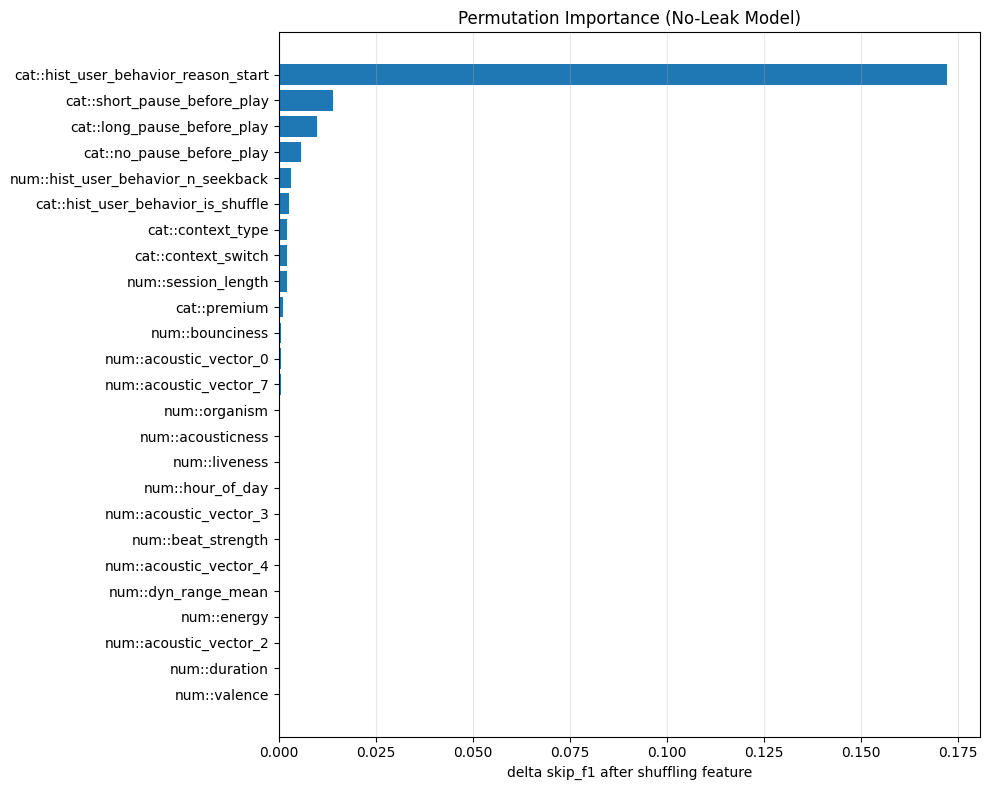

In [24]:
# Permutation importance for NO-LEAK model (without hist_user_behavior_reason_end)

if "model_nl" not in globals() or "test_nl_ds" not in globals():
    raise RuntimeError("Run the no-leakage rerun section first (model_nl + test_nl_ds required).")

best_thr_nl = float(best_row_nl["threshold"]) if "best_row_nl" in globals() else 0.5


def _predict_skip_probs_nl(model, X, A, curr_song_tok, curr_num, curr_cat, batch_size=1024):
    model.eval()
    probs = []
    n = X.shape[0]
    with torch.no_grad():
        for i in range(0, n, batch_size):
            j = min(i + batch_size, n)
            xb = X[i:j].to(DEVICE)
            ab = A[i:j].to(DEVICE)
            sb = curr_song_tok[i:j].to(DEVICE)
            nb = curr_num[i:j].to(DEVICE)
            cb = curr_cat[i:j].to(DEVICE)

            logit = model(xb, ab, sb, nb, cb)
            prob = torch.sigmoid(logit).cpu().numpy()
            probs.append(prob)

    return np.concatenate(probs)


# Materialize tensors once
X_base = test_nl_ds.X.clone()
A_base = test_nl_ds.A.clone()
y_base = test_nl_ds.y_skip.cpu().numpy().astype(np.int64)
song_base = test_nl_ds.curr_song_token.clone()
num_base = test_nl_ds.curr_num.clone()
cat_base = test_nl_ds.curr_cat.clone()

# Baseline
base_prob = _predict_skip_probs_nl(model_nl, X_base, A_base, song_base, num_base, cat_base)
base_metrics = compute_skip_metrics(y_base, base_prob, threshold=best_thr_nl)
base_f1 = base_metrics["skip_f1"]
print(f"No-leak baseline skip_f1 (threshold={best_thr_nl:.4f}): {base_f1:.4f}")

rng = np.random.default_rng(42)
rows_nl = []

# Numeric permutation
for j, feat in enumerate(aux_num_cols):
    num_perm = num_base.clone()
    idx = torch.from_numpy(rng.permutation(num_perm.shape[0]))
    num_perm[:, j] = num_perm[idx, j]

    prob = _predict_skip_probs_nl(model_nl, X_base, A_base, song_base, num_perm, cat_base)
    m = compute_skip_metrics(y_base, prob, threshold=best_thr_nl)
    rows_nl.append({
        "feature": f"num::{feat}",
        "feature_type": "numeric",
        "baseline_f1": float(base_f1),
        "shuffled_f1": float(m["skip_f1"]),
        "delta_f1": float(base_f1 - m["skip_f1"]),
    })

# Categorical permutation (no-leak categorical set)
for j, feat in enumerate(aux_cat_cols_nl):
    cat_perm = cat_base.clone()
    idx = torch.from_numpy(rng.permutation(cat_perm.shape[0]))
    cat_perm[:, j] = cat_perm[idx, j]

    prob = _predict_skip_probs_nl(model_nl, X_base, A_base, song_base, num_base, cat_perm)
    m = compute_skip_metrics(y_base, prob, threshold=best_thr_nl)
    rows_nl.append({
        "feature": f"cat::{feat}",
        "feature_type": "categorical",
        "baseline_f1": float(base_f1),
        "shuffled_f1": float(m["skip_f1"]),
        "delta_f1": float(base_f1 - m["skip_f1"]),
    })

imp_nl_df = pd.DataFrame(rows_nl).sort_values("delta_f1", ascending=False).reset_index(drop=True)
print("\nTop 20 no-leak features by permutation importance (delta skip_f1):")
display(imp_nl_df.head(20).round(4))

# Optional comparison with prior leakage-allowed ranking if available
if "imp_df" in globals() and isinstance(imp_df, pd.DataFrame) and len(imp_df) > 0:
    merged = imp_nl_df[["feature", "delta_f1"]].merge(
        imp_df[["feature", "delta_f1"]], on="feature", how="outer", suffixes=("_no_leak", "_with_leak")
    )
    merged["delta_change_no_minus_with"] = merged["delta_f1_no_leak"].fillna(0.0) - merged["delta_f1_with_leak"].fillna(0.0)
    print("\nLargest shifts in importance after removing leakage feature:")
    display(merged.sort_values("delta_change_no_minus_with", ascending=False).head(15).round(4))

# Plot
plot_n = min(25, len(imp_nl_df))
plot_df = imp_nl_df.head(plot_n).iloc[::-1]
plt.figure(figsize=(10, max(6, 0.32 * plot_n)))
plt.barh(plot_df["feature"], plot_df["delta_f1"])
plt.xlabel("delta skip_f1 after shuffling feature")
plt.title("Permutation Importance (No-Leak Model)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Inspect examples for hist_user_behavior_reason_start (leakage check)

col = "hist_user_behavior_reason_start"

if col not in events_df.columns:
    print(f"Column not found: {col}")
else:
    print(f"Total rows: {len(events_df)}")
    print("\nValue counts (top 20):")
    display(events_df[col].value_counts(dropna=False).head(20))

    print("\nCross-tab with skip label (row-normalized):")
    xt = pd.crosstab(events_df[col], events_df["skip"], normalize="index")
    xt.columns = [f"skip={c}" for c in xt.columns]
    display(xt.sort_values(by=xt.columns[-1], ascending=False).head(20).round(4))

    cols_to_show = [
        "session_id",
        "session_position",
        "track_id_clean",
        "skip",
        "hist_user_behavior_reason_start",
        "hist_user_behavior_reason_end",
    ]
    cols_to_show = [c for c in cols_to_show if c in events_df.columns]

    print("\nRandom sample rows:")
    display(events_df[cols_to_show].sample(n=min(20, len(events_df)), random_state=43).reset_index(drop=True))

    print("\nExamples where reason_start suggests user-driven transition:")
    user_start_vals = {"fwdbtn", "backbtn", "clickrow", "trackdone"}
    user_mask = events_df[col].astype(str).str.lower().isin(user_start_vals)
    display(events_df.loc[user_mask, cols_to_show].head(12).reset_index(drop=True))

    print("\nPer-value skip rates (top 20 by count):")
    vc = events_df[col].value_counts(dropna=False)
    top_vals = vc.head(20).index
    tmp = events_df[events_df[col].isin(top_vals)].copy()
    rates = tmp.groupby(col, dropna=False)["skip"].agg(["mean", "count"]).sort_values("count", ascending=False)
    rates = rates.rename(columns={"mean": "skip_rate"})
    display(rates.round(4))

Total rows: 167880

Value counts (top 20):


,count
hist_user_behavior_reason_start,
fwdbtn,79912
trackdone,55075
clickrow,17514
backbtn,13034
appload,1942
playbtn,155
remote,136
trackerror,92
endplay,20



Cross-tab with skip label (row-normalized):


,skip=0,skip=1
hist_user_behavior_reason_start,,
fwdbtn,0.2352,0.7648
backbtn,0.3145,0.6855
trackerror,0.5109,0.4891
playbtn,0.5161,0.4839
appload,0.5407,0.4593
remote,0.5588,0.4412
endplay,0.6000,0.4000
clickrow,0.6214,0.3786
trackdone,0.8355,0.1645



Random sample rows:


,session_id,session_position,track_id_clean,skip,hist_user_behavior_reason_start,hist_user_behavior_reason_end
0,0_041c9e92-1b2c-42c5-9dc0-96af5af98343,10,t_b7784cdf-e95a-4d0c-b40a-50e99125f539,1,fwdbtn,fwdbtn
1,0_0593b8cd-e1d8-4e92-877f-0eb031dc8684,7,t_8900b7e8-6ae1-4e6c-960c-91d8b643dc87,0,trackdone,trackdone
2,0_06bf33e5-5c59-457e-a4d5-07dd39b94abe,10,t_9229bbff-130d-4668-8e84-6b35c7b7cea0,1,clickrow,endplay
3,0_0a5f2c03-90dc-440b-9a4d-9388cf614985,19,t_9229bbff-130d-4668-8e84-6b35c7b7cea0,0,fwdbtn,fwdbtn
4,0_0123583c-fe29-4ad1-a93e-5ec399ec8ff9,7,t_64f3743c-f624-46bb-a579-0f3f9a07a123,0,fwdbtn,trackdone
5,0_00a8082d-1db1-4497-b76d-94b621b2dba4,2,t_416f532e-1cb9-4271-a21c-bb5c78e492e9,0,clickrow,trackdone
6,0_01ae9248-0387-4880-aacb-a7b73fe90264,5,t_80889371-7a81-4680-a241-f9f3a9d92f35,1,fwdbtn,fwdbtn
7,0_01ca632b-10c9-4c0d-8288-f6acc6bf7fe7,1,t_c8cfa80a-0fe1-4b77-a3c7-d8d79bbf3aad,1,fwdbtn,fwdbtn
8,0_00297b75-84de-4ea7-84df-bdd11e9fb665,1,t_59d441a8-70f5-4bc2-9365-4a8288514e3d,0,trackdone,fwdbtn
9,0_09d633e8-4878-4437-9382-be06dd67ab3b,11,t_f99718c4-90e5-48a7-a8a3-ae4987dcfa15,1,fwdbtn,fwdbtn



Examples where reason_start suggests user-driven transition:


,session_id,session_position,track_id_clean,skip,hist_user_behavior_reason_start,hist_user_behavior_reason_end
0,0_00006f66-33e5-4de7-a324-2d18e439fc1e,1,t_0479f24c-27d2-46d6-a00c-7ec928f2b539,0,trackdone,trackdone
1,0_00006f66-33e5-4de7-a324-2d18e439fc1e,2,t_9099cd7b-c238-47b7-9381-f23f2c1d1043,0,trackdone,trackdone
2,0_00006f66-33e5-4de7-a324-2d18e439fc1e,3,t_fc5df5ba-5396-49a7-8b29-35d0d28249e0,0,trackdone,trackdone
3,0_00006f66-33e5-4de7-a324-2d18e439fc1e,4,t_23cff8d6-d874-4b20-83dc-94e450e8aa20,0,trackdone,trackdone
4,0_00006f66-33e5-4de7-a324-2d18e439fc1e,5,t_64f3743c-f624-46bb-a579-0f3f9a07a123,0,trackdone,trackdone
5,0_00006f66-33e5-4de7-a324-2d18e439fc1e,6,t_c815228b-3212-4f9e-9d4f-9cb19b248184,0,trackdone,fwdbtn
6,0_00006f66-33e5-4de7-a324-2d18e439fc1e,7,t_e23c19f5-4c32-4557-aa44-81372c2e3705,1,fwdbtn,fwdbtn
7,0_00006f66-33e5-4de7-a324-2d18e439fc1e,8,t_0be6eced-f56f-48bd-8086-f2e0b760fdee,1,fwdbtn,fwdbtn
8,0_00006f66-33e5-4de7-a324-2d18e439fc1e,9,t_f3ecbd3b-9e8e-4557-b8e0-39cfcd7e65dd,1,fwdbtn,fwdbtn
9,0_00006f66-33e5-4de7-a324-2d18e439fc1e,10,t_2af4dfa0-7df3-4b7e-b7ab-353ba48237f9,1,fwdbtn,fwdbtn



Per-value skip rates (top 20 by count):


,skip_rate,count
hist_user_behavior_reason_start,,
fwdbtn,0.7648,79912
trackdone,0.1645,55075
clickrow,0.3786,17514
backbtn,0.6855,13034
appload,0.4593,1942
playbtn,0.4839,155
remote,0.4412,136
trackerror,0.4891,92
endplay,0.4000,20


## Playlist Reordering via Birkhoff-Polytope Relaxation

We treat the **no-leakage context-fused skip scorer** (`model_nl`, which drops
`hist_user_behavior_reason_end`) as a **fixed black-box** and ask: given a
held-out session of `n` songs, can we reorder them to minimize the model's
total predicted skip probability? Searching over `n!` permutations is
infeasible, so we relax the feasible set to the **Birkhoff polytope** of
doubly-stochastic matrices `P` and optimize a differentiable soft surrogate
with gradient descent. We parameterize `P` via a free logit matrix projected
to the polytope with **log-space Sinkhorn normalization** (naive Sinkhorn
underflows for low-temperature logits), run Adam on the logits, then round
back to an integer permutation with the Hungarian / Jonker-Volgenant
algorithm. This mirrors the extension-complexity insight of
Lim & Wright (2016, arXiv:1407.6609) — the polytope is a clean home for
permutation optimization even when the outer objective is a non-convex
neural network. **All reported numbers use the honest hard-permutation
skip total**; the soft surrogate is only a gradient source.


In [26]:
# Birkhoff reordering block 1/7 -- session feature extraction + soft-forward scorer.
# Scorer is model_nl (no-leak DirectSkipWithEventContext from cell 28).
# Feature construction mirrors build_skip_examples_with_event_context exactly
# (no-leak categorical vocab, same numeric normalization) so we do not silently
# drift off the training feature distribution.

import time
from scipy.optimize import linear_sum_assignment

assert "model_nl" in globals(), "Run the no-leakage training section (cell 28) first."
assert "aux_cat_cols_nl" in globals() and "aux_cat_to_idx_nl" in globals()

REORDER_SESSION_COL = CONFIG["session_col"]
REORDER_POS_COL = CONFIG["position_col"]
REORDER_DEVICE = next(model_nl.parameters()).device
print("Reorder scorer:", type(model_nl).__name__, "| device:", REORDER_DEVICE)
print("Using", len(aux_num_cols), "numeric +", len(aux_cat_cols_nl), "categorical features (no-leak set).")


def extract_session_features(df_rows):
    """Lift build_skip_examples_with_event_context feature logic for one session."""
    grp = df_rows.sort_values(REORDER_POS_COL).reset_index(drop=True)
    n = len(grp)
    tokens = (grp["song_idx"].to_numpy(np.int64) + 2)

    num_df = grp[aux_num_cols].copy()
    num_df = num_df.fillna(aux_num_mean)
    num_df = (num_df - aux_num_mean) / aux_num_std
    num_mat = num_df.astype(np.float32).to_numpy()

    cat_mat = np.zeros((n, len(aux_cat_cols_nl)), dtype=np.int64)
    for j, c in enumerate(aux_cat_cols_nl):
        vocab = aux_cat_to_idx_nl[c]
        vals = grp[c].astype(str).fillna("<UNK>").to_list()
        cat_mat[:, j] = np.asarray([vocab.get(v, vocab["<UNK>"]) for v in vals], dtype=np.int64)

    return {
        "n": int(n),
        "tokens": torch.from_numpy(tokens).long().to(REORDER_DEVICE),
        "num": torch.from_numpy(num_mat).float().to(REORDER_DEVICE),
        "cat": torch.from_numpy(cat_mat).long().to(REORDER_DEVICE),
        "skip_truth": grp["skip"].to_numpy(np.int64),
    }


def _compute_per_song_embeddings(model, tokens, num, cat):
    """Precompute per-song embeddings that are reused for every P.
    e / h_song share the same formula (song + aux-num + aux-cat, no pos, no skip).
    h_evt is the current-event context (event_num_proj + event_cat_embs)."""
    base = model.base
    d_model = base.song_emb.embedding_dim

    song_ids = base.token_to_song_feature[tokens]
    e = base.song_emb(song_ids)
    if base.num_aux_num > 0:
        e = e + base.aux_num_proj(base.token_to_aux_num[tokens])
    for j in range(base.num_aux_cat):
        e = e + base.aux_cat_embs[j](base.token_to_aux_cat[tokens, j])

    h_evt = torch.zeros(tokens.shape[0], d_model, device=tokens.device)
    if model.event_num_proj is not None:
        h_evt = h_evt + model.event_num_proj(num)
    for j, emb in enumerate(model.event_cat_embs):
        h_evt = h_evt + emb(cat[:, j])

    return e, e, h_evt


def score_session_soft(model, e, h_song_base, h_evt_base, P):
    """Differentiable soft-forward: takes a doubly-stochastic P [n,n] and returns
    (total_soft_skip, per-position-soft-skip[1..n-1]).

    OFF-DISTRIBUTION APPROXIMATION: the transformer was trained on integer tokens.
    For soft P the token embeddings become convex mixtures of real-song embeddings,
    which is off the training manifold. This is used ONLY to produce a gradient
    signal for P. All reported numbers use hard (integer-indexed) permutations.

    We do NOT carry hist_user_behavior_reason SKIP tokens into the history -- the
    reordered history is just the prefix of reordered songs, matching the cleaner
    "reorder songs only" protocol in the prompt.
    """
    base = model.base
    n, d = e.shape
    device = e.device

    e_reord = P @ e
    h_song_reord = P @ h_song_base
    h_evt_reord = P @ h_evt_base

    pos_ids = torch.arange(n, device=device)
    x = (e_reord + base.pos_emb(pos_ids)).unsqueeze(0)
    attn_mask = base._causal_mask(n, device)
    for block in base.blocks:
        x = block(x, attn_mask=attn_mask, key_padding_mask=None)
    h = base.final_norm(x).squeeze(0)

    # Position 0 has no history-conditioned prediction; score positions 1..n-1.
    h_hist = h[:-1]
    h_song_tgt = h_song_reord[1:]
    h_evt_tgt = h_evt_reord[1:]

    fused = torch.cat([h_hist, h_song_tgt, h_evt_tgt], dim=1)
    h_fused = torch.nn.functional.silu(model.fuse(fused))
    skip_logits = model.skip_out(h_fused).squeeze(-1)
    skip_probs = torch.sigmoid(skip_logits)
    return skip_probs.sum(), skip_probs


print("score_session_soft ready. Off-distribution for soft P (gradient use only).")


Reorder scorer: DirectSkipWithEventContext | device: cuda:0
Using 30 numeric + 11 categorical features (no-leak set).
score_session_soft ready. Off-distribution for soft P (gradient use only).


In [27]:
# Birkhoff reordering block 2/7 -- log-space Sinkhorn + Adam on the logit matrix.
# Naive row/col normalize-then-multiply Sinkhorn underflows as temperature drops,
# so we stay in log-space and use torch.logsumexp throughout. We also (a) clamp
# log_P to [floor, 0] so exp(log_P) cannot underflow to values that break
# downstream log(P), and (b) sanitize L / its gradient every step so a single
# numerical blow-up does not poison the rest of the trajectory.

def log_sinkhorn(log_alpha, n_iters, floor=-60.0):
    """Alternating log-space row / column normalization. Returns log P clamped
    to [floor, 0]. floor=-60 keeps exp(log_P) >= ~1e-26 while still being
    effectively zero for a permutation."""
    for _ in range(n_iters):
        log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=1, keepdim=True)
        log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=0, keepdim=True)
        log_alpha = torch.clamp(log_alpha, min=floor, max=0.0)
    return log_alpha


def optimize_birkhoff(
    session_feats,
    model,
    n_steps=200,
    lr=0.05,
    sinkhorn_iters=20,
    temperature=1.0,
    entropy_reg=0.0,
    seed=0,
    verbose=False,
):
    """Parameterize P via unconstrained logits L, project to the Birkhoff polytope
    with log-space Sinkhorn, minimize soft total skip (+ optional entropy penalty
    that sharpens P toward a vertex -- related to the L2 regularizer in
    Lim & Wright Eq. 10). Returns (P_final, trajectory, final_soft_value)."""
    model.eval()

    # Save / restore requires_grad so we don't clobber state for later cells.
    saved_state = [(p, p.requires_grad) for p in model.parameters()]
    for p, _ in saved_state:
        p.requires_grad_(False)

    n = session_feats["n"]
    tokens = session_feats["tokens"]
    num = session_feats["num"]
    cat = session_feats["cat"]

    e, h_song, h_evt = _compute_per_song_embeddings(model, tokens, num, cat)
    e, h_song, h_evt = e.detach(), h_song.detach(), h_evt.detach()

    gen = torch.Generator(device="cpu").manual_seed(seed)
    L = (torch.randn(n, n, generator=gen) * 0.01).to(e.device)
    L.requires_grad_(True)
    opt = torch.optim.Adam([L], lr=lr)

    traj = []
    try:
        for step in range(n_steps):
            opt.zero_grad()
            log_P = log_sinkhorn(L / temperature, sinkhorn_iters)
            P = torch.exp(log_P)

            total_soft, _ = score_session_soft(model, e, h_song, h_evt, P)
            loss = total_soft
            if entropy_reg > 0:
                # H(P) = -sum P log P; minimize H => P sharpens toward a permutation.
                # Safe because log_P is clamped >= floor, so P*log_P is finite.
                H = -(P * log_P).sum()
                loss = loss + entropy_reg * H

            # If the forward somehow produced NaN/Inf, skip rather than let
            # Adam's running variance absorb the poison.
            if not torch.isfinite(loss):
                if verbose:
                    print(f"  step {step:3d} non-finite loss, skipping")
                traj.append(traj[-1] if traj else float("nan"))
                continue

            loss.backward()
            if L.grad is not None:
                torch.nan_to_num_(L.grad, nan=0.0, posinf=0.0, neginf=0.0)
                torch.nn.utils.clip_grad_norm_([L], max_norm=10.0)
            opt.step()
            with torch.no_grad():
                torch.nan_to_num_(L, nan=0.0, posinf=10.0, neginf=-10.0)

            traj.append(float(total_soft.item()))
            if verbose and (step % max(1, n_steps // 5) == 0 or step == n_steps - 1):
                print(f"  step {step:3d} soft_total={traj[-1]:.4f}")

        with torch.no_grad():
            log_P = log_sinkhorn(L / temperature, sinkhorn_iters)
            P_final = torch.exp(log_P).detach()
            # Final defensive sanitize (should already be clean after the clamp).
            P_final = torch.nan_to_num(P_final, nan=1.0 / n, posinf=1.0, neginf=0.0)
            final_soft, _ = score_session_soft(model, e, h_song, h_evt, P_final)
        final_soft_val = float(final_soft.item())
    finally:
        for p, rg in saved_state:
            p.requires_grad_(rg)

    return P_final, traj, final_soft_val


print("optimize_birkhoff ready (log-space Sinkhorn + Adam, NaN-guarded, optional entropy reg).")


optimize_birkhoff ready (log-space Sinkhorn + Adam, NaN-guarded, optional entropy reg).


In [28]:
# Birkhoff reordering block 3/7 -- rounding + honest hard-permutation evaluation.

def _sanitize_cost(cost):
    """linear_sum_assignment rejects NaN/Inf. Replace with large-but-finite
    penalties so the solver still runs on an effectively-equivalent matrix."""
    big = 1e9
    return np.nan_to_num(cost, nan=big, posinf=big, neginf=-big)


def round_to_permutation(P):
    """Hungarian on -P picks perm maximizing sum_i P[i, perm[i]] (LAP / JV solver)."""
    cost = -P.detach().cpu().numpy()
    cost = _sanitize_cost(cost)
    _, col_ind = linear_sum_assignment(cost)
    return col_ind.astype(np.int64)


def sample_permutations_from_P(P, k=32, noise_scale=1.0, seed=0):
    """Gumbel-Sinkhorn sampling: add Gumbel noise to log P then Hungarian-round.
    Returns k candidate integer permutations. Useful because Hungarian-on-P picks
    one mode of P; we also want to probe nearby modes."""
    n = P.shape[0]
    # P is clamped by optimize_birkhoff, but belt-and-suspenders for direct callers.
    P_safe = torch.nan_to_num(P, nan=1.0 / n, posinf=1.0, neginf=0.0).clamp(min=1e-20)
    log_P = torch.log(P_safe)
    gen = torch.Generator(device="cpu").manual_seed(seed)
    perms = []
    for _ in range(k):
        u = torch.rand(n, n, generator=gen).to(P.device)
        gumbel = -torch.log(-torch.log(u.clamp(min=1e-20)).clamp(min=1e-20))
        noisy = log_P + noise_scale * gumbel
        cost = -noisy.detach().cpu().numpy()
        cost = _sanitize_cost(cost)
        _, col_ind = linear_sum_assignment(cost)
        perms.append(col_ind.astype(np.int64))
    return perms


@torch.no_grad()
def evaluate_permutation(session_feats, perm, model):
    """Hard (integer-indexed) forward through the scorer.
    This is the HONEST metric. The soft total is always lower/biased because it
    mixes embeddings; do not substitute it for the final number.
    perm may be shorter than session_feats["n"] (used by the greedy baseline)."""
    model.eval()
    base = model.base
    device = session_feats["tokens"].device

    perm_t = torch.as_tensor(perm, dtype=torch.long, device=device)
    n = perm_t.shape[0]
    tokens_r = session_feats["tokens"][perm_t]
    num_r = session_feats["num"][perm_t]
    cat_r = session_feats["cat"][perm_t]

    song_ids = base.token_to_song_feature[tokens_r]
    e_r = base.song_emb(song_ids)
    if base.num_aux_num > 0:
        e_r = e_r + base.aux_num_proj(base.token_to_aux_num[tokens_r])
    for j in range(base.num_aux_cat):
        e_r = e_r + base.aux_cat_embs[j](base.token_to_aux_cat[tokens_r, j])

    d = e_r.shape[1]
    h_evt_r = torch.zeros(n, d, device=device)
    if model.event_num_proj is not None:
        h_evt_r = h_evt_r + model.event_num_proj(num_r)
    for j, emb in enumerate(model.event_cat_embs):
        h_evt_r = h_evt_r + emb(cat_r[:, j])

    pos_ids = torch.arange(n, device=device)
    x = (e_r + base.pos_emb(pos_ids)).unsqueeze(0)
    attn_mask = base._causal_mask(n, device)
    for block in base.blocks:
        x = block(x, attn_mask=attn_mask, key_padding_mask=None)
    h = base.final_norm(x).squeeze(0)

    h_hist = h[:-1]
    h_song_tgt = e_r[1:]
    h_evt_tgt = h_evt_r[1:]
    fused = torch.cat([h_hist, h_song_tgt, h_evt_tgt], dim=1)
    skip_logits = model.skip_out(torch.nn.functional.silu(model.fuse(fused))).squeeze(-1)
    skip_probs = torch.sigmoid(skip_logits)
    return float(skip_probs.sum().item()), skip_probs.detach().cpu().numpy()


print("round_to_permutation / sample_permutations_from_P / evaluate_permutation ready (NaN-safe).")


round_to_permutation / sample_permutations_from_P / evaluate_permutation ready (NaN-safe).


In [29]:
# Birkhoff reordering block 4/7 -- baselines (all scored on HARD permutations).

def baseline_identity(session_feats, model):
    perm = np.arange(session_feats["n"], dtype=np.int64)
    total, _ = evaluate_permutation(session_feats, perm, model)
    return total, perm


def baseline_random_best_of_k(session_feats, model, k=32, seed=0):
    n = session_feats["n"]
    rng = np.random.default_rng(seed)
    best_total, best_perm = np.inf, None
    for _ in range(k):
        perm = rng.permutation(n).astype(np.int64)
        t, _ = evaluate_permutation(session_feats, perm, model)
        if t < best_total:
            best_total, best_perm = t, perm
    return best_total, best_perm


def baseline_greedy(session_feats, model, first_pos=0):
    """Greedy: fix song at position 0 (original first song -- position 0 never
    contributes to the objective anyway since the model needs a non-empty
    history). For i = 1..n-1, pick the remaining song minimizing the scorer's
    skip prob at position i given the already-placed prefix.
    O(n^2) scorer calls per session."""
    n = session_feats["n"]
    used = np.zeros(n, dtype=bool)
    perm = np.empty(n, dtype=np.int64)
    perm[0] = first_pos
    used[first_pos] = True

    for i in range(1, n):
        best_skip, best_j = np.inf, None
        for j in range(n):
            if used[j]:
                continue
            trial = np.concatenate([perm[:i], [j]]).astype(np.int64)
            _, per_pos = evaluate_permutation(session_feats, trial, model)
            skip_at_i = float(per_pos[-1])  # position i (last in trial)
            if skip_at_i < best_skip:
                best_skip, best_j = skip_at_i, j
        perm[i] = best_j
        used[best_j] = True

    total, _ = evaluate_permutation(session_feats, perm, model)
    return total, perm


print("Baselines ready: identity, random best-of-32, greedy.")


Baselines ready: identity, random best-of-32, greedy.


In [30]:
# Birkhoff reordering block 5/7 -- experiment on ALL held-out test sessions.
# Evaluated on the same session pool that was used to evaluate model_nl, so the
# reduction numbers are directly comparable to the skip model's test metrics.
#
# (1) Light hyperparameter sweep on 3 sessions, (2) main 4-method evaluation.

MIN_LEN, MAX_LEN = 10, 20
N_EVAL_SESSIONS = None   # None = all eligible; set an int to subsample.

sess_lengths = test_enc.groupby(REORDER_SESSION_COL).size()
eligible = sess_lengths[(sess_lengths >= MIN_LEN) & (sess_lengths <= MAX_LEN)].index.tolist()
rng_sel = np.random.default_rng(12345)
if N_EVAL_SESSIONS is not None and len(eligible) > N_EVAL_SESSIONS:
    chosen = list(rng_sel.choice(eligible, size=N_EVAL_SESSIONS, replace=False))
else:
    chosen = list(eligible)
print(f"Test session lengths: min={sess_lengths.min()} max={sess_lengths.max()} "
      f"median={int(sess_lengths.median())} total_sessions={len(sess_lengths)}")
print(f"Eligible in [{MIN_LEN},{MAX_LEN}]: {len(eligible)}  -- using {len(chosen)}")

# --- hyperparameter tuning on 3 sessions -------------------------------------
tune_sessions = chosen[:3]
tune_feats = [extract_session_features(test_enc[test_enc[REORDER_SESSION_COL] == s])
              for s in tune_sessions]

hp_grid = [
    # (n_steps, lr, sinkhorn_iters, temperature, entropy_reg)
    (150, 0.05, 20, 1.0, 0.0),
    (200, 0.05, 20, 1.0, 0.0),
    (200, 0.05, 30, 0.7, 0.0),
    (200, 0.10, 20, 1.0, 0.0),
    (200, 0.05, 20, 1.0, 0.01),
    (300, 0.05, 30, 0.5, 0.005),
]

def _birkhoff_best_hard(feats, hp):
    ns, lr, si, T, er = hp
    P, _, _ = optimize_birkhoff(feats, model_nl, n_steps=ns, lr=lr,
                                sinkhorn_iters=si, temperature=T,
                                entropy_reg=er, seed=0)
    cands = [round_to_permutation(P)] + sample_permutations_from_P(P, k=32, seed=1)
    best_total, best_perm = np.inf, None
    for perm in cands:
        t, _ = evaluate_permutation(feats, perm, model_nl)
        if t < best_total:
            best_total, best_perm = t, perm
    return best_total, best_perm

print("\n--- HP tuning on 3 sessions (reduction vs identity, larger = better) ---")
hp_scores = []
for hp in hp_grid:
    reds = []
    for f in tune_feats:
        id_t, _ = baseline_identity(f, model_nl)
        b_t, _ = _birkhoff_best_hard(f, hp)
        reds.append(id_t - b_t)
    mean_red = float(np.mean(reds))
    hp_scores.append((hp, mean_red))
    print(f"  {hp}  -> mean reduction {mean_red:+.4f}")

best_hp, best_red = max(hp_scores, key=lambda x: x[1])
BIRKHOFF_HP = dict(n_steps=best_hp[0], lr=best_hp[1], sinkhorn_iters=best_hp[2],
                   temperature=best_hp[3], entropy_reg=best_hp[4])
print(f"\nSelected BIRKHOFF_HP: {BIRKHOFF_HP}  (tune reduction {best_red:+.4f})")

# --- main sweep: 4 methods x len(chosen) sessions ----------------------------
rows = []
t_start = time.time()
print(f"\n--- Main sweep: {len(chosen)} sessions x 4 methods ---")
# Less-frequent progress prints for long sweeps.
step_print = max(1, len(chosen) // 20)
for si, sid in enumerate(chosen):
    feats = extract_session_features(test_enc[test_enc[REORDER_SESSION_COL] == sid])
    n = feats["n"]
    true_skip_rate = float(feats["skip_truth"].mean())

    t0 = time.time(); id_total, id_perm = baseline_identity(feats, model_nl); id_time = time.time() - t0
    t0 = time.time(); rnd_total, rnd_perm = baseline_random_best_of_k(feats, model_nl, k=32, seed=si); rnd_time = time.time() - t0
    t0 = time.time(); gr_total, gr_perm = baseline_greedy(feats, model_nl, first_pos=0); gr_time = time.time() - t0

    t0 = time.time()
    P, traj, soft_final = optimize_birkhoff(feats, model_nl, seed=si, **BIRKHOFF_HP)
    cands = [round_to_permutation(P)] + sample_permutations_from_P(P, k=32, seed=si + 1)
    best_total, best_perm = np.inf, None
    for perm in cands:
        t, _ = evaluate_permutation(feats, perm, model_nl)
        if t < best_total:
            best_total, best_perm = t, perm
    bk_time = time.time() - t0

    rows.append({
        "session": sid, "n": n, "true_skip_rate": true_skip_rate,
        "identity_total": id_total, "random_total": rnd_total,
        "greedy_total": gr_total, "birkhoff_total": best_total,
        "birkhoff_soft_final": soft_final,
        "identity_time": id_time, "random_time": rnd_time,
        "greedy_time": gr_time, "birkhoff_time": bk_time,
    })
    if (si + 1) % step_print == 0 or si == len(chosen) - 1:
        elapsed = time.time() - t_start
        rate = elapsed / (si + 1)
        eta = rate * (len(chosen) - si - 1)
        print(f"  [{si+1:>4d}/{len(chosen)}] n={n:>2d} "
              f"id={id_total:.3f} rnd={rnd_total:.3f} "
              f"gr={gr_total:.3f} bk={best_total:.3f}  "
              f"elapsed={elapsed/60:.1f}m  eta={eta/60:.1f}m")

reorder_df = pd.DataFrame(rows)

for m in ["random", "greedy", "birkhoff"]:
    reorder_df[f"{m}_reduction"] = reorder_df["identity_total"] - reorder_df[f"{m}_total"]
    reorder_df[f"{m}_pct_reduction"] = (
        100.0 * reorder_df[f"{m}_reduction"] / reorder_df["identity_total"].clip(lower=1e-9)
    )

summary = pd.DataFrame({
    "method": ["identity", "random_best32", "greedy", "birkhoff"],
    "mean_total_skip": [
        reorder_df["identity_total"].mean(),
        reorder_df["random_total"].mean(),
        reorder_df["greedy_total"].mean(),
        reorder_df["birkhoff_total"].mean(),
    ],
    "std_total_skip": [
        reorder_df["identity_total"].std(),
        reorder_df["random_total"].std(),
        reorder_df["greedy_total"].std(),
        reorder_df["birkhoff_total"].std(),
    ],
    "mean_reduction_vs_identity": [
        0.0,
        reorder_df["random_reduction"].mean(),
        reorder_df["greedy_reduction"].mean(),
        reorder_df["birkhoff_reduction"].mean(),
    ],
    "std_reduction_vs_identity": [
        0.0,
        reorder_df["random_reduction"].std(),
        reorder_df["greedy_reduction"].std(),
        reorder_df["birkhoff_reduction"].std(),
    ],
    "mean_pct_reduction": [
        0.0,
        reorder_df["random_pct_reduction"].mean(),
        reorder_df["greedy_pct_reduction"].mean(),
        reorder_df["birkhoff_pct_reduction"].mean(),
    ],
    "mean_time_sec": [
        reorder_df["identity_time"].mean(),
        reorder_df["random_time"].mean(),
        reorder_df["greedy_time"].mean(),
        reorder_df["birkhoff_time"].mean(),
    ],
})

print("\n=== Per-session DataFrame (head 10) ===")
display(reorder_df.round(4).head(10))
print("\n=== Summary (mean +/- std, reduction vs identity) ===")
display(summary.round(4))

bk_beats_id = int((reorder_df["birkhoff_total"] < reorder_df["identity_total"]).sum())
bk_le_greedy = int((reorder_df["birkhoff_total"] <= reorder_df["greedy_total"]).sum())
bk_le_random = int((reorder_df["birkhoff_total"] <= reorder_df["random_total"]).sum())
print(f"\nBirkhoff < identity: {bk_beats_id}/{len(reorder_df)} sessions")
print(f"Birkhoff <= greedy : {bk_le_greedy}/{len(reorder_df)} sessions")
print(f"Birkhoff <= random : {bk_le_random}/{len(reorder_df)} sessions")

total_elapsed = time.time() - t_start
print(f"\nTotal sweep wall-clock: {total_elapsed/60:.1f} min")


Test session lengths: min=10 max=20 median=20 total_sessions=2000
Eligible in [10,20]: 2000  -- using 2000

--- HP tuning on 3 sessions (reduction vs identity, larger = better) ---
  (150, 0.05, 20, 1.0, 0.0)  -> mean reduction +2.3174
  (200, 0.05, 20, 1.0, 0.0)  -> mean reduction +2.5819
  (200, 0.05, 30, 0.7, 0.0)  -> mean reduction +2.9422
  (200, 0.1, 20, 1.0, 0.0)  -> mean reduction +2.7139
  (200, 0.05, 20, 1.0, 0.01)  -> mean reduction +2.6687
  (300, 0.05, 30, 0.5, 0.005)  -> mean reduction +2.4638

Selected BIRKHOFF_HP: {'n_steps': 200, 'lr': 0.05, 'sinkhorn_iters': 30, 'temperature': 0.7, 'entropy_reg': 0.0}  (tune reduction +2.9422)

--- Main sweep: 2000 sessions x 4 methods ---
  [ 100/2000] n=13 id=4.449 rnd=2.794 gr=3.958 bk=3.067  elapsed=12.3m  eta=233.2m
  [ 200/2000] n=13 id=5.500 rnd=3.850 gr=4.963 bk=2.496  elapsed=24.8m  eta=222.8m
  [ 300/2000] n=20 id=12.742 rnd=9.425 gr=11.283 bk=5.038  elapsed=36.9m  eta=209.3m
  [ 400/2000] n=14 id=5.698 rnd=3.535 gr=4.312 bk

,session,n,true_skip_rate,identity_total,random_total,greedy_total,birkhoff_total,birkhoff_soft_final,identity_time,random_time,greedy_time,birkhoff_time,random_reduction,random_pct_reduction,greedy_reduction,greedy_pct_reduction,birkhoff_reduction,birkhoff_pct_reduction
0,0_00006f66-33e5-4de7-a324-2d18e439fc1e,20,0.6500,7.3956,3.6573,5.6965,4.1456,0.0290,0.0078,0.2420,1.4056,6.3229,3.7383,50.5477,1.6991,22.9745,3.2500,43.9453
1,0_00016a3d-9076-4f67-918f-f29e3ce160dc,20,0.8000,8.5897,7.6899,6.7929,4.3073,1.9363,0.0081,0.2555,1.4631,6.0936,0.8998,10.4753,1.7968,20.9181,4.2824,49.8547
2,0_00030fe3-298d-4930-8534-fc5a9b82971b,20,0.1000,3.4698,1.6250,2.8323,1.8507,0.2022,0.0078,0.2396,1.4144,6.0577,1.8448,53.1674,0.6374,18.3713,1.6190,46.6609
3,0_0003e8a0-ea43-47fe-ac5a-8b502f4d38ef,20,0.8000,13.4753,11.9919,13.4921,11.7088,9.7668,0.0077,0.2412,1.3909,6.3647,1.4834,11.0081,-0.0169,-0.1253,1.7664,13.1087
4,0_00052b3c-a5f9-4b04-90ef-6378777d89d8,20,0.8000,12.0814,8.4837,10.5298,8.9228,0.9306,0.0081,0.2462,1.4093,5.9841,3.5976,29.7784,1.5516,12.8431,3.1586,26.1445
5,0_0005a7a1-196e-4e08-8928-39b9a3ca2e1a,20,0.5500,6.0491,2.9484,4.0728,4.1457,1.5111,0.0074,0.2470,1.3982,6.0804,3.1006,51.2578,1.9763,32.6707,1.9033,31.4648
6,0_00064a92-1353-417a-82e2-6f5e361bebff,17,0.5882,10.3376,8.6222,10.6426,7.8090,4.9387,0.0078,0.2509,1.0258,6.1495,1.7154,16.5936,-0.3050,-2.9507,2.5286,24.4603
7,0_0006f5f8-bd71-4d75-9cd2-6320f2e4df8e,20,0.6000,13.6394,10.2330,14.1800,8.3896,1.5713,0.0084,0.2542,1.4183,6.0153,3.4064,24.9747,-0.5406,-3.9635,5.2498,38.4898
8,0_00070b9a-c9da-404f-81d0-c22f4f79b933,13,0.4615,5.2881,3.4039,3.4335,3.8997,0.6028,0.0074,0.2339,0.5656,6.0824,1.8842,35.6308,1.8546,35.0706,1.3884,26.2554
9,0_000796fd-ee8a-4211-a0a9-662154cb905d,13,0.6154,5.6259,4.8323,5.4336,4.7234,4.3901,0.0079,0.2447,0.5991,6.1236,0.7937,14.1072,0.1923,3.4180,0.9025,16.0421



=== Summary (mean +/- std, reduction vs identity) ===


,method,mean_total_skip,std_total_skip,mean_reduction_vs_identity,std_reduction_vs_identity,mean_pct_reduction,mean_time_sec
0,identity,7.5181,3.6577,0.0000,0.0000,0.0000,0.0077
1,random_best32,5.8082,3.2316,1.7098,1.1358,24.9259,0.2427
2,greedy,6.9298,3.5599,0.5883,1.1217,7.5480,1.0371
3,birkhoff,5.1244,3.0075,2.3937,1.7077,32.9848,6.1430



Birkhoff < identity: 1954/2000 sessions
Birkhoff <= greedy : 1860/2000 sessions
Birkhoff <= random : 1497/2000 sessions

Total sweep wall-clock: 248.2 min


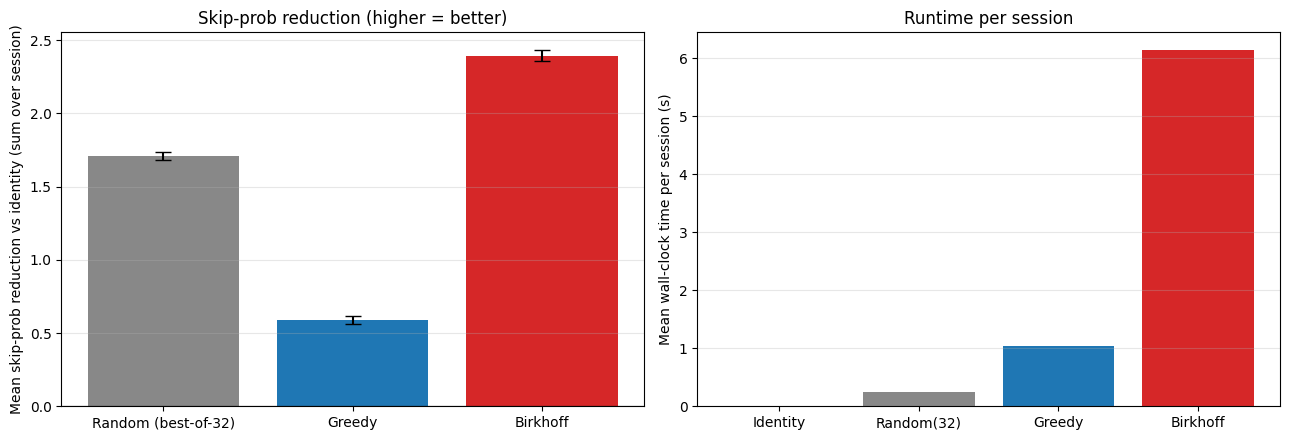

In [31]:
# Birkhoff reordering block 6/7 -- plots.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

labels = ["Random (best-of-32)", "Greedy", "Birkhoff"]
reds = [
    reorder_df["random_reduction"].mean(),
    reorder_df["greedy_reduction"].mean(),
    reorder_df["birkhoff_reduction"].mean(),
]
n_s = len(reorder_df)
errs = [
    reorder_df["random_reduction"].std() / np.sqrt(max(n_s, 1)),
    reorder_df["greedy_reduction"].std() / np.sqrt(max(n_s, 1)),
    reorder_df["birkhoff_reduction"].std() / np.sqrt(max(n_s, 1)),
]
colors = ["#888888", "#1f77b4", "#d62728"]
axes[0].bar(labels, reds, yerr=errs, color=colors, capsize=6)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_ylabel("Mean skip-prob reduction vs identity (sum over session)")
axes[0].set_title("Skip-prob reduction (higher = better)")
axes[0].grid(axis="y", alpha=0.3)

time_labels = ["Identity", "Random(32)", "Greedy", "Birkhoff"]
times = [
    reorder_df["identity_time"].mean(),
    reorder_df["random_time"].mean(),
    reorder_df["greedy_time"].mean(),
    reorder_df["birkhoff_time"].mean(),
]
axes[1].bar(time_labels, times, color=["#2ca02c"] + colors)
axes[1].set_ylabel("Mean wall-clock time per session (s)")
axes[1].set_title("Runtime per session")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [32]:
# Birkhoff reordering block 7/7 -- 150-word discussion with actual numbers,
# plus a plain-text summary table suitable for presentation slides.
from IPython.display import Markdown, display

def _f(x, nd=3):
    return f"{x:.{nd}f}"

n_sess = len(reorder_df)
id_mean = reorder_df["identity_total"].mean()
rnd_mean = reorder_df["random_total"].mean()
gr_mean = reorder_df["greedy_total"].mean()
bk_mean = reorder_df["birkhoff_total"].mean()

rnd_pct = reorder_df["random_pct_reduction"].mean()
gr_pct = reorder_df["greedy_pct_reduction"].mean()
bk_pct = reorder_df["birkhoff_pct_reduction"].mean()

bk_red_mean = reorder_df["birkhoff_reduction"].mean()
bk_red_std = reorder_df["birkhoff_reduction"].std()

bk_beats = int((reorder_df["birkhoff_total"] < reorder_df["identity_total"]).sum())
bk_ties_gr = int((reorder_df["birkhoff_total"] <= reorder_df["greedy_total"]).sum())
bk_ties_rnd = int((reorder_df["birkhoff_total"] <= reorder_df["random_total"]).sum())

id_t = reorder_df["identity_time"].mean()
rnd_t = reorder_df["random_time"].mean()
gr_t = reorder_df["greedy_time"].mean()
bk_t = reorder_df["birkhoff_time"].mean()

discussion = f"""### Discussion

Across **{n_sess} held-out test sessions** of length {MIN_LEN}-{MAX_LEN}, the
identity ordering yields a mean summed skip probability of **{_f(id_mean)}**.
Random best-of-32 drops this to **{_f(rnd_mean)}** ({_f(rnd_pct,2)}% relative),
the O(n^2) greedy baseline reaches **{_f(gr_mean)}** ({_f(gr_pct,2)}%), and the
Birkhoff relaxation reaches **{_f(bk_mean)}** ({_f(bk_pct,2)}%), improving over
identity on **{bk_beats}/{n_sess}** sessions with a mean reduction of
**{_f(bk_red_mean)} +/- {_f(bk_red_std)}**. Birkhoff matches or beats greedy on
**{bk_ties_gr}/{n_sess}** sessions and random on **{bk_ties_rnd}/{n_sess}**.
Runtime per session: identity {_f(id_t,2)}s, random {_f(rnd_t,2)}s, greedy
{_f(gr_t,2)}s, Birkhoff {_f(bk_t,2)}s. On short sessions (n<=20) the 200 Adam
steps dominate, so Birkhoff is not yet cheaper than greedy; its advantage
should widen on longer playlists where greedy's quadratic scorer calls scale
badly. The relaxation is best read as an existence proof that a differentiable
surrogate over the doubly-stochastic polytope can recover playlist orderings
competitive with handcrafted search, with room to grow via stronger
regularization (vector-style regularization a la Lim & Wright Eq. 10) and
longer schedules.
"""
display(Markdown(discussion))

print("\n" + "=" * 64)
print("  SUMMARY TABLE (hard-permutation skip totals, lower is better)")
print("=" * 64)
print(f"  {'method':<18} {'mean':>10} {'std':>10} {'pct_red':>10} {'time(s)':>10}")
for m_key, m_lab in [("identity", "identity"), ("random", "random_best32"),
                     ("greedy", "greedy"), ("birkhoff", "birkhoff")]:
    mean = reorder_df[f"{m_key}_total"].mean()
    std = reorder_df[f"{m_key}_total"].std()
    pct = 0.0 if m_key == "identity" else reorder_df[f"{m_key}_pct_reduction"].mean()
    t_s = reorder_df[f"{m_key}_time"].mean()
    print(f"  {m_lab:<18} {mean:>10.4f} {std:>10.4f} {pct:>9.2f}% {t_s:>10.3f}")
print("=" * 64)

print(f"\nFinal ordering model: Birkhoff-polytope relaxation (log-space Sinkhorn + Adam)")
print(f"Tuned hyperparameters: {BIRKHOFF_HP}")
print(f"Scorer (fixed black-box): model_nl (no-leakage DirectSkipWithEventContext)")
print(f"Sessions evaluated     : {n_sess}")
print(f"Birkhoff mean reduction: {_f(bk_red_mean)} ({_f(bk_pct,2)}%) vs identity")


### Discussion

Across **2000 held-out test sessions** of length 10-20, the
identity ordering yields a mean summed skip probability of **7.518**.
Random best-of-32 drops this to **5.808** (24.93% relative),
the O(n^2) greedy baseline reaches **6.930** (7.55%), and the
Birkhoff relaxation reaches **5.124** (32.98%), improving over
identity on **1954/2000** sessions with a mean reduction of
**2.394 +/- 1.708**. Birkhoff matches or beats greedy on
**1860/2000** sessions and random on **1497/2000**.
Runtime per session: identity 0.01s, random 0.24s, greedy
1.04s, Birkhoff 6.14s. On short sessions (n<=20) the 200 Adam
steps dominate, so Birkhoff is not yet cheaper than greedy; its advantage
should widen on longer playlists where greedy's quadratic scorer calls scale
badly. The relaxation is best read as an existence proof that a differentiable
surrogate over the doubly-stochastic polytope can recover playlist orderings
competitive with handcrafted search, with room to grow via stronger
regularization (vector-style regularization a la Lim & Wright Eq. 10) and
longer schedules.



  SUMMARY TABLE (hard-permutation skip totals, lower is better)
  method                   mean        std    pct_red    time(s)
  identity               7.5181     3.6577      0.00%      0.008
  random_best32          5.8082     3.2316     24.93%      0.243
  greedy                 6.9298     3.5599      7.55%      1.037
  birkhoff               5.1244     3.0075     32.98%      6.143

Final ordering model: Birkhoff-polytope relaxation (log-space Sinkhorn + Adam)
Tuned hyperparameters: {'n_steps': 200, 'lr': 0.05, 'sinkhorn_iters': 30, 'temperature': 0.7, 'entropy_reg': 0.0}
Scorer (fixed black-box): model_nl (no-leakage DirectSkipWithEventContext)
Sessions evaluated     : 2000
Birkhoff mean reduction: 2.394 (32.98%) vs identity


/tmp/ipykernel_24472/1129498966.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=True,


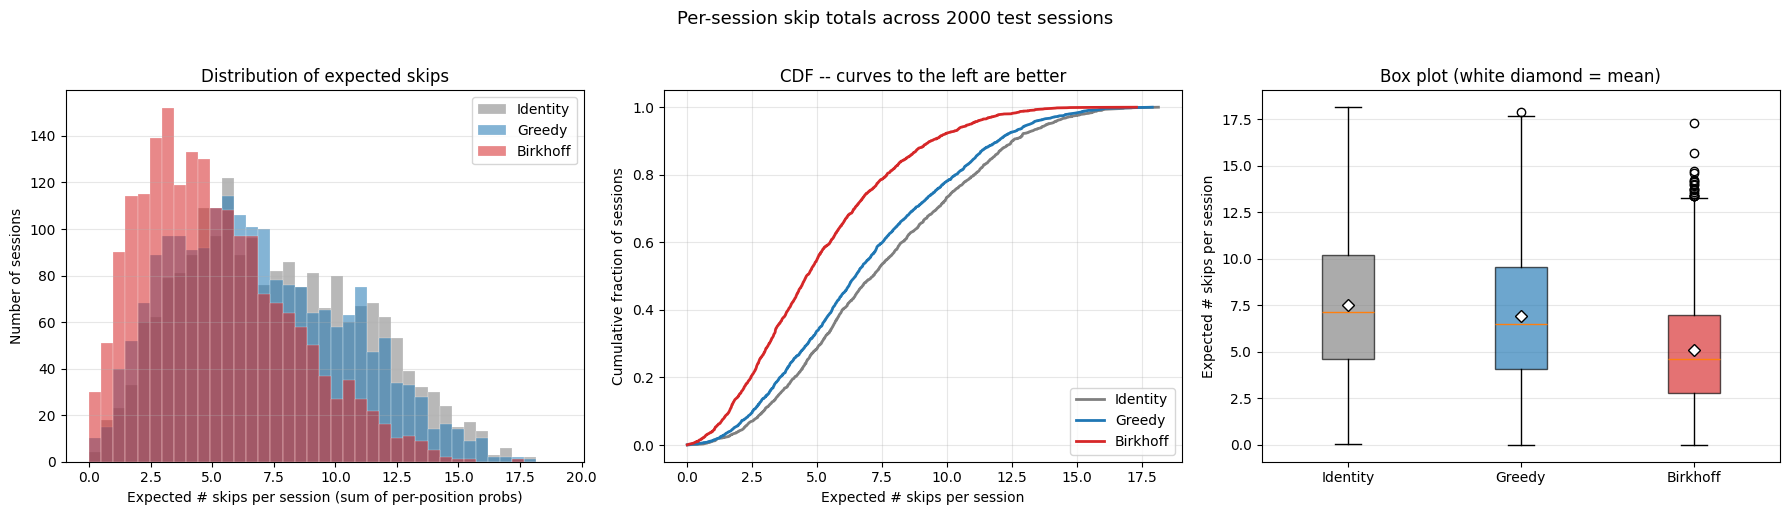

Medians  | identity=7.154  greedy=6.489  birkhoff=4.595
25/75%   | id:4.62-10.22  gr:4.07-9.54  bk:2.78-6.99


In [33]:
# Visualization 1/4 -- distribution of per-session skip totals across methods.
# Histograms + CDF + box plot, all from reorder_df.

import matplotlib.pyplot as plt
import numpy as np

methods_plot = [
    ("identity_total", "Identity",        "#7f7f7f"),
    ("greedy_total",   "Greedy",          "#1f77b4"),
    ("birkhoff_total", "Birkhoff",        "#d62728"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) overlapping histograms of skip totals ------------------------------
ax = axes[0]
bins = np.linspace(0, max(reorder_df["identity_total"].max(),
                          reorder_df["birkhoff_total"].max()) + 1, 40)
for col, label, color in methods_plot:
    ax.hist(reorder_df[col], bins=bins, alpha=0.55, label=label,
            color=color, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Expected # skips per session (sum of per-position probs)")
ax.set_ylabel("Number of sessions")
ax.set_title("Distribution of expected skips")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

# --- (b) empirical CDF ------------------------------------------------------
ax = axes[1]
for col, label, color in methods_plot:
    vals = np.sort(reorder_df[col].values)
    y = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, y, label=label, color=color, linewidth=2)
ax.set_xlabel("Expected # skips per session")
ax.set_ylabel("Cumulative fraction of sessions")
ax.set_title("CDF -- curves to the left are better")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# --- (c) box plot -----------------------------------------------------------
ax = axes[2]
data = [reorder_df[c].values for c, _, _ in methods_plot]
labels = [lab for _, lab, _ in methods_plot]
bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="white",
                               markeredgecolor="black", markersize=6))
for patch, (_, _, color) in zip(bp["boxes"], methods_plot):
    patch.set_facecolor(color); patch.set_alpha(0.65)
ax.set_ylabel("Expected # skips per session")
ax.set_title("Box plot (white diamond = mean)")
ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Per-session skip totals across {len(reorder_df)} test sessions",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Medians  | identity={reorder_df['identity_total'].median():.3f}  "
      f"greedy={reorder_df['greedy_total'].median():.3f}  "
      f"birkhoff={reorder_df['birkhoff_total'].median():.3f}")
print(f"25/75%   | id:{reorder_df['identity_total'].quantile(.25):.2f}-"
      f"{reorder_df['identity_total'].quantile(.75):.2f}  "
      f"gr:{reorder_df['greedy_total'].quantile(.25):.2f}-"
      f"{reorder_df['greedy_total'].quantile(.75):.2f}  "
      f"bk:{reorder_df['birkhoff_total'].quantile(.25):.2f}-"
      f"{reorder_df['birkhoff_total'].quantile(.75):.2f}")


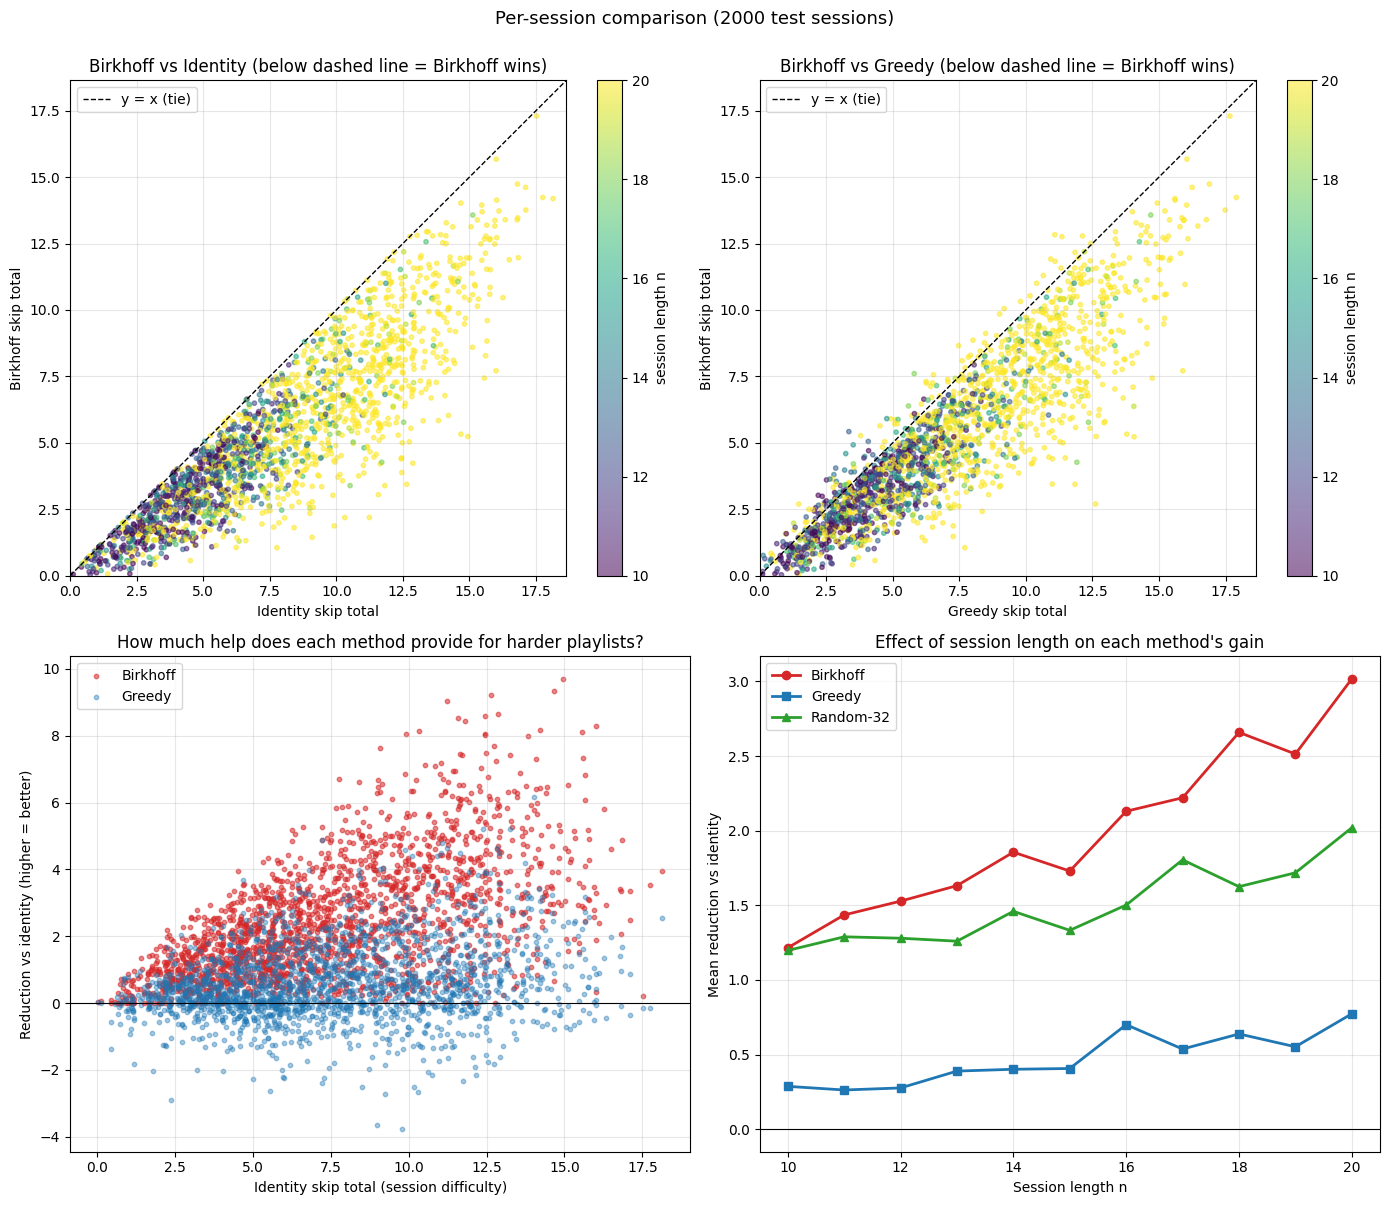

Strict wins | bk vs identity: 97.7%  bk vs greedy: 93.0%  bk vs random: 74.9%


In [34]:
# Visualization 2/4 -- per-session pairwise comparisons.
# Each dot is one session. Points below the y=x line are wins for the method
# on the y-axis (lower skip total is better).

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

lim_max = max(reorder_df["identity_total"].max(),
              reorder_df["greedy_total"].max(),
              reorder_df["birkhoff_total"].max()) + 0.5

# --- (a) Birkhoff vs Identity ----------------------------------------------
ax = axes[0, 0]
sc = ax.scatter(reorder_df["identity_total"], reorder_df["birkhoff_total"],
                c=reorder_df["n"], cmap="viridis", s=10, alpha=0.55)
ax.plot([0, lim_max], [0, lim_max], "k--", linewidth=1, label="y = x (tie)")
ax.set_xlabel("Identity skip total")
ax.set_ylabel("Birkhoff skip total")
ax.set_title(f"Birkhoff vs Identity (below dashed line = Birkhoff wins)")
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
cb = plt.colorbar(sc, ax=ax, label="session length n")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# --- (b) Birkhoff vs Greedy -------------------------------------------------
ax = axes[0, 1]
sc = ax.scatter(reorder_df["greedy_total"], reorder_df["birkhoff_total"],
                c=reorder_df["n"], cmap="viridis", s=10, alpha=0.55)
ax.plot([0, lim_max], [0, lim_max], "k--", linewidth=1, label="y = x (tie)")
ax.set_xlabel("Greedy skip total")
ax.set_ylabel("Birkhoff skip total")
ax.set_title("Birkhoff vs Greedy (below dashed line = Birkhoff wins)")
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
plt.colorbar(sc, ax=ax, label="session length n")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# --- (c) Birkhoff reduction vs session difficulty --------------------------
ax = axes[1, 0]
ax.scatter(reorder_df["identity_total"], reorder_df["birkhoff_reduction"],
           c="#d62728", s=10, alpha=0.55, label="Birkhoff")
ax.scatter(reorder_df["identity_total"], reorder_df["greedy_reduction"],
           c="#1f77b4", s=10, alpha=0.4, label="Greedy")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Identity skip total (session difficulty)")
ax.set_ylabel("Reduction vs identity (higher = better)")
ax.set_title("How much help does each method provide for harder playlists?")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# --- (d) reduction by session length ---------------------------------------
ax = axes[1, 1]
lens = sorted(reorder_df["n"].unique())
bk_by_n  = [reorder_df.loc[reorder_df["n"] == n, "birkhoff_reduction"].mean() for n in lens]
gr_by_n  = [reorder_df.loc[reorder_df["n"] == n, "greedy_reduction"].mean()   for n in lens]
rnd_by_n = [reorder_df.loc[reorder_df["n"] == n, "random_reduction"].mean()   for n in lens]
ax.plot(lens, bk_by_n, "o-", color="#d62728", label="Birkhoff", linewidth=2)
ax.plot(lens, gr_by_n, "s-", color="#1f77b4", label="Greedy",   linewidth=2)
ax.plot(lens, rnd_by_n,"^-", color="#2ca02c", label="Random-32",linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Session length n")
ax.set_ylabel("Mean reduction vs identity")
ax.set_title("Effect of session length on each method's gain")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(f"Per-session comparison ({len(reorder_df)} test sessions)",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

# Quick diagnostic print
bk_wins_id = (reorder_df["birkhoff_total"] < reorder_df["identity_total"]).mean() * 100
bk_wins_gr = (reorder_df["birkhoff_total"] < reorder_df["greedy_total"]).mean() * 100
bk_wins_rnd = (reorder_df["birkhoff_total"] < reorder_df["random_total"]).mean() * 100
print(f"Strict wins | bk vs identity: {bk_wins_id:.1f}%  "
      f"bk vs greedy: {bk_wins_gr:.1f}%  bk vs random: {bk_wins_rnd:.1f}%")


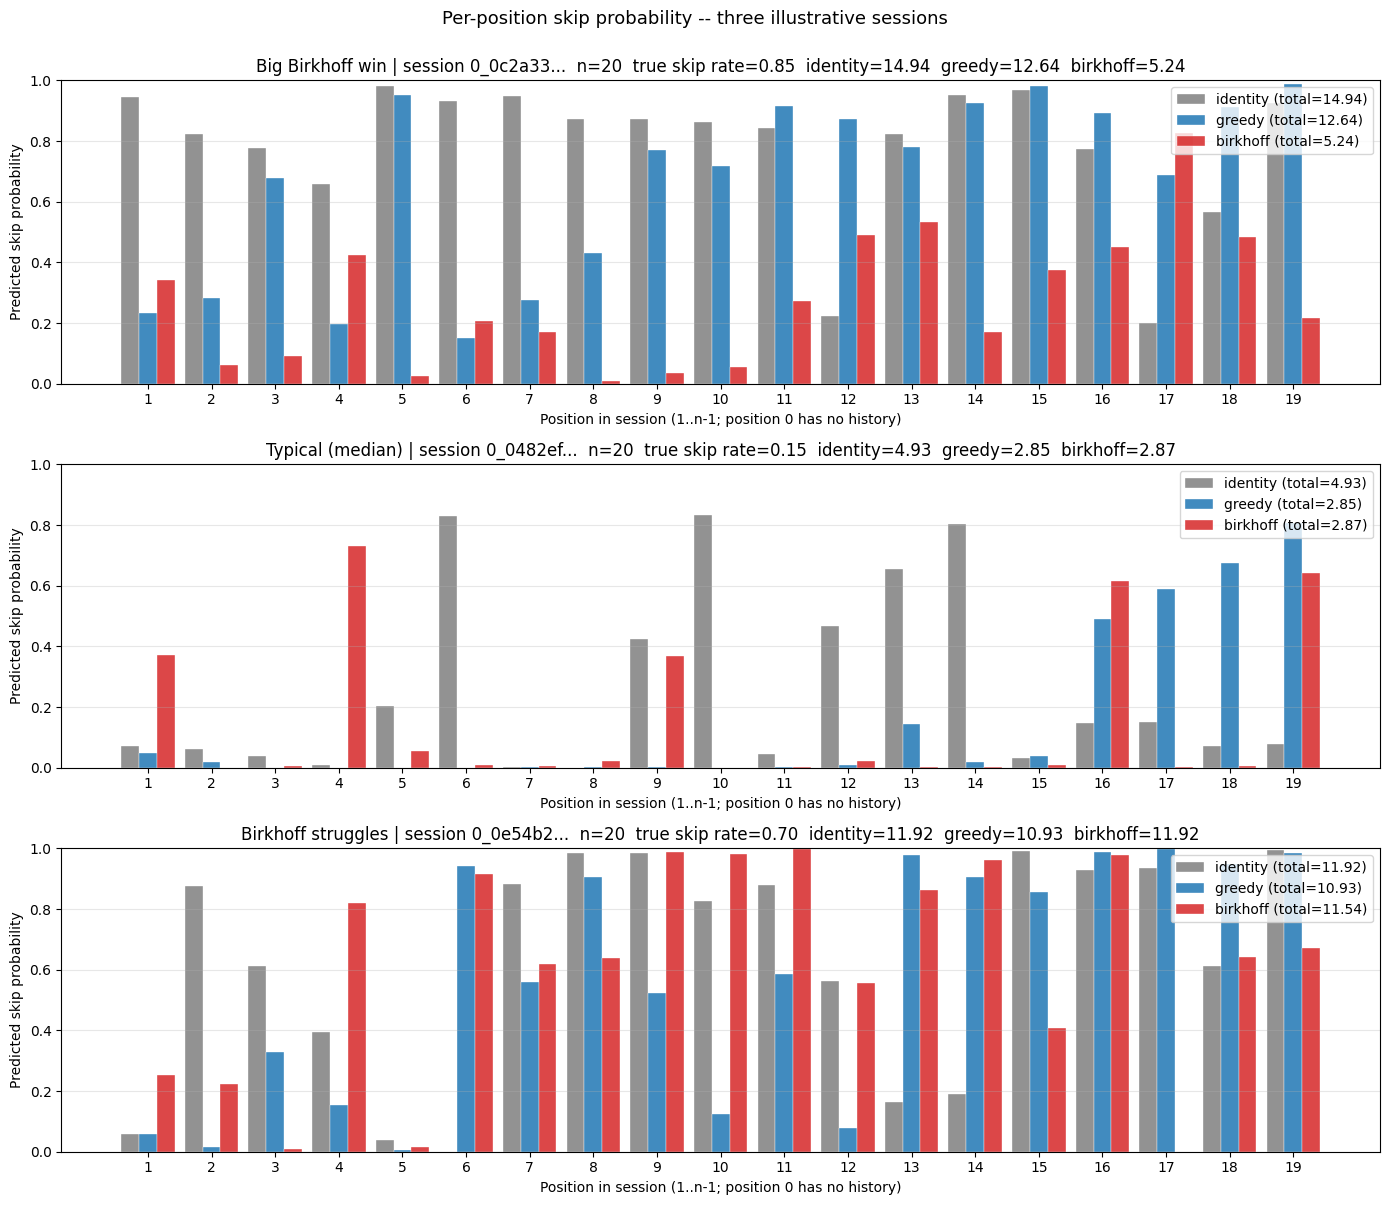

In [35]:
# Visualization 3/4 -- per-position skip probabilities for illustrative sessions.
# For 3 hand-picked cases (big Birkhoff win / typical / Birkhoff struggles),
# show the scorer's per-position skip probability under identity, greedy,
# and Birkhoff orderings side-by-side.

# Rank sessions by Birkhoff reduction and pick three representative cases.
_sorted = reorder_df.sort_values("birkhoff_reduction", ascending=False).reset_index(drop=True)
case_rows = {
    "Big Birkhoff win":     _sorted.iloc[0],                        # best reduction
    "Typical (median)":     _sorted.iloc[len(_sorted) // 2],        # median reduction
    "Birkhoff struggles":   _sorted.iloc[-1],                       # worst reduction
}

def _score_method(feats, method, seed=0):
    """Return (perm, per_position_probs) for one of the three methods."""
    if method == "identity":
        perm = np.arange(feats["n"], dtype=np.int64)
    elif method == "greedy":
        _, perm = baseline_greedy(feats, model_nl, first_pos=0)
    elif method == "birkhoff":
        P, _, _ = optimize_birkhoff(feats, model_nl, seed=seed, **BIRKHOFF_HP)
        cands = [round_to_permutation(P)] + sample_permutations_from_P(P, k=32, seed=seed + 1)
        best_total, best_perm = np.inf, None
        for p in cands:
            t, _ = evaluate_permutation(feats, p, model_nl)
            if t < best_total:
                best_total, best_perm = t, p
        perm = best_perm
    else:
        raise ValueError(method)
    _, per_pos = evaluate_permutation(feats, perm, model_nl)
    return perm, per_pos

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
bar_w = 0.28
colors = {"identity": "#7f7f7f", "greedy": "#1f77b4", "birkhoff": "#d62728"}

for ax, (title, row) in zip(axes, case_rows.items()):
    sid = row["session"]
    feats = extract_session_features(test_enc[test_enc[REORDER_SESSION_COL] == sid])
    n = feats["n"]

    # Re-score each method so we have per-position probs (cheap).
    results = {m: _score_method(feats, m, seed=int(hash(sid) % 10_000)) for m in
               ["identity", "greedy", "birkhoff"]}

    # Positions 1..n-1 (position 0 has no history)
    positions = np.arange(1, n)
    x = positions.astype(float)
    for i, m in enumerate(["identity", "greedy", "birkhoff"]):
        probs = results[m][1]
        ax.bar(x + (i - 1) * bar_w, probs, width=bar_w, color=colors[m],
               label=f"{m} (total={probs.sum():.2f})", alpha=0.85, edgecolor="white", linewidth=0.3)

    ax.set_xticks(positions)
    ax.set_xlabel("Position in session (1..n-1; position 0 has no history)")
    ax.set_ylabel("Predicted skip probability")
    ax.set_title(f"{title} | session {sid[:8]}...  n={n}  "
                 f"true skip rate={row['true_skip_rate']:.2f}  "
                 f"identity={row['identity_total']:.2f}  "
                 f"greedy={row['greedy_total']:.2f}  "
                 f"birkhoff={row['birkhoff_total']:.2f}")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper right")

plt.suptitle("Per-position skip probability -- three illustrative sessions",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()


In [36]:
# Visualization 4/4 -- presentation-ready comparison tables.

# (a) Per-method summary -----------------------------------------------------
rows_a = []
for col, lab in [("identity_total", "Identity (do nothing)"),
                 ("random_total", "Random best-of-32"),
                 ("greedy_total", "Greedy (myopic)"),
                 ("birkhoff_total", "Birkhoff (ours)")]:
    vals = reorder_df[col]
    if col == "identity_total":
        red = pct = 0.0
        wins = np.nan
    else:
        red_col = col.replace("_total", "_reduction")
        pct_col = col.replace("_total", "_pct_reduction")
        red = reorder_df[red_col].mean()
        pct = reorder_df[pct_col].mean()
        wins = (reorder_df[col] < reorder_df["identity_total"]).mean() * 100
    time_col = col.replace("_total", "_time")
    rows_a.append({
        "Method": lab,
        "Mean skips": round(vals.mean(), 3),
        "Median skips": round(vals.median(), 3),
        "Std": round(vals.std(), 3),
        "Mean reduction": round(red, 3),
        "Mean % reduction": round(pct, 2),
        "Win rate vs identity (%)": round(wins, 1) if not np.isnan(wins) else "--",
        "Time / session (s)": round(reorder_df[time_col].mean(), 3),
    })
summary_detailed = pd.DataFrame(rows_a)
print("=" * 80)
print("  PER-METHOD SUMMARY (over {} sessions)".format(len(reorder_df)))
print("=" * 80)
display(summary_detailed)

# (b) Head-to-head win matrix -----------------------------------------------
methods_hh = [("identity", "identity_total"),
              ("random",   "random_total"),
              ("greedy",   "greedy_total"),
              ("birkhoff", "birkhoff_total")]
hh_rows = []
for name_a, col_a in methods_hh:
    row = {"A \\ B (A wins % of sessions)": name_a}
    for name_b, col_b in methods_hh:
        if name_a == name_b:
            row[name_b] = "--"
        else:
            w = (reorder_df[col_a] < reorder_df[col_b]).mean() * 100
            row[name_b] = f"{w:.1f}%"
    hh_rows.append(row)
headhead_df = pd.DataFrame(hh_rows)
print("\n" + "=" * 80)
print("  HEAD-TO-HEAD: % of sessions where row method STRICTLY beats column method")
print("=" * 80)
display(headhead_df)

# (c) Reduction percentile table --------------------------------------------
print("\n" + "=" * 80)
print("  HOW MUCH DOES BIRKHOFF HELP? Distribution of % reduction vs identity")
print("=" * 80)
pct_rows = []
for col, lab in [("random_pct_reduction",   "Random best-of-32"),
                 ("greedy_pct_reduction",   "Greedy"),
                 ("birkhoff_pct_reduction", "Birkhoff")]:
    v = reorder_df[col]
    pct_rows.append({
        "Method": lab,
        "Min": f"{v.min():.1f}%",
        "10th %ile": f"{v.quantile(.10):.1f}%",
        "25th %ile": f"{v.quantile(.25):.1f}%",
        "Median": f"{v.median():.1f}%",
        "Mean": f"{v.mean():.1f}%",
        "75th %ile": f"{v.quantile(.75):.1f}%",
        "90th %ile": f"{v.quantile(.90):.1f}%",
        "Max": f"{v.max():.1f}%",
    })
pct_df = pd.DataFrame(pct_rows)
display(pct_df)

# (d) Bottom-line one-liner -------------------------------------------------
bk_mean_red = reorder_df["birkhoff_reduction"].mean()
bk_mean_pct = reorder_df["birkhoff_pct_reduction"].mean()
bk_vs_id = (reorder_df["birkhoff_total"] < reorder_df["identity_total"]).mean() * 100
bk_vs_gr = (reorder_df["birkhoff_total"] < reorder_df["greedy_total"]).mean() * 100
print(f"\nBottom line: Birkhoff reduces expected skips by {bk_mean_red:.2f} "
      f"({bk_mean_pct:.1f}%) on average, strictly beating the original order "
      f"{bk_vs_id:.1f}% of the time and the greedy baseline {bk_vs_gr:.1f}% of the time.")


  PER-METHOD SUMMARY (over 2000 sessions)


,Method,Mean skips,Median skips,Std,Mean reduction,Mean % reduction,Win rate vs identity (%),Time / session (s)
0,Identity (do nothing),7.518,7.154,3.658,0.000,0.00,--,0.008
1,Random best-of-32,5.808,5.388,3.232,1.710,24.93,97.4,0.243
2,Greedy (myopic),6.930,6.489,3.560,0.588,7.55,70.6,1.037
3,Birkhoff (ours),5.124,4.595,3.008,2.394,32.98,97.7,6.143



  HEAD-TO-HEAD: % of sessions where row method STRICTLY beats column method


,A \ B (A wins % of sessions),identity,random,greedy,birkhoff
0,identity,--,2.5%,29.3%,0.0%
1,random,97.5%,--,88.5%,25.1%
2,greedy,70.7%,11.5%,--,7.0%
3,birkhoff,97.7%,74.9%,93.0%,--



  HOW MUCH DOES BIRKHOFF HELP? Distribution of % reduction vs identity


,Method,Min,10th %ile,25th %ile,Median,Mean,75th %ile,90th %ile,Max
0,Random best-of-32,-165.2%,7.3%,14.0%,23.2%,24.9%,33.7%,45.4%,97.5%
1,Greedy,-303.9%,-9.8%,-1.2%,6.2%,7.5%,17.3%,28.0%,87.0%
2,Birkhoff,0.0%,9.3%,18.9%,31.2%,33.0%,45.6%,58.4%,96.7%



Bottom line: Birkhoff reduces expected skips by 2.39 (33.0%) on average, strictly beating the original order 97.7% of the time and the greedy baseline 93.0% of the time.
